# **Análisis Exploratorio**

## **Importación de Librerías**

Se importan las librerías esenciales para facilitar el análisis, que abarca la carga de datos, la visualización, la transformación, la fusión y la unión. Además, se configura el entorno para suprimir las advertencias (`warnings`) y asegurar que la salida del código sea más limpia y enfocada en los resultados.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy

from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor

## **Lectura del Dataset**

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.  
`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# Se unen X e y (ambos son DataFrames) con el fin de facilitar el EDA
df = pd.concat([X, y], axis=1) 


Se muestran las primeras filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [3]:
print(df.head().to_string())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
0       1         1          1   40       1       0                     0             0       0        1                  0              1            0        5        18        15         1    0    9          4       3                0
1       0         0          0   25       1       0                     0             1       0        0                  0              0            1        3         0         0         0    0    7          6       1                0
2       1         1          1   28       0       0                     0             0       1        0                  0              1            1        5        30        30         1    0    9          4       8                0
3       1         0          1   27       0       0 

Se muestran las últimas filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [4]:
print(df.tail().to_string())

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
253675       1         1          1   45       0       0                     0             0       1        1                  0              1            0        3         0         5         0    1    5          6       7                0
253676       1         1          1   18       0       0                     0             0       0        0                  0              1            0        4         0         0         1    0   11          2       4                1
253677       0         0          1   28       0       0                     0             1       1        0                  0              1            0        1         0         0         0    0    2          5       2                0
253678       1         0        

Se presenta un resumen detallado de todas las variables del dataset, incluyendo su rol (predictora o objetivo), el tipo de dato (numérico, categórico, binario) y la identificación de valores faltantes, lo que permite evaluar la integridad y estructura de los datos para su posterior procesamiento.

In [5]:
df.shape

(253680, 22)

In [6]:
print(cdc_diabetes_health_indicators.variables) 

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

Este conjunto de datos contiene información relacionada con factores de salud y demográficos asociados a la diabetes. La variable objetivo (`Diabetes_binary`) indica si un paciente tiene diabetes o prediabetes (1) o no (0). Entre las características destacan variables binarias como `HighBP` (hipertensión alta), `HighChol` (colesterol alto) y `Smoker` (fumador), que representan condiciones médicas o hábitos relevantes. También se incluyen variables numéricas como `BMI` (índice de masa corporal) y escalas de salud general (`GenHlth`, `MentHlth`, `PhysHlth`), que miden percepciones y estados de salud física y mental. Además, hay atributos demográficos como `Sex` (sexo), `Age` (edad), `Education` (nivel educativo) e `Income` (ingresos), que permiten analizar patrones según grupos poblacionales. La ausencia de valores faltantes facilita el análisis, y las descripciones detalladas de cada campo ayudan a contextualizar su relevancia clínica. 

### **Valores Únicos**

Se calcula el número de valores únicos para cada variable del DataFrame.

In [7]:
df.nunique()

HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
Diabetes_binary          2
dtype: int64

El análisis de valores únicos revela una estructura clara y consistente con la naturaleza de las variables descritas. Las variables binarias muestran exactamente 2 valores únicos (0 y 1), confirmando su correcta codificación como indicadores binarios de presencia/ausencia de condiciones médicas, hábitos o características demográficas. Las variables numéricas muestran mayor dispersión: `BMI` presenta 84 valores únicos, reflejando la diversidad esperada en índices de masa corporal, mientras que `MentHlth` y `PhysHlth` muestran 31 valores cada una (correspondiendo a los posibles días de afectación en los últimos 30 días). Estos resultados validan la integridad del conjunto de datos y confirman que todas las variables mantienen los rangos y categorías esperados según su descripción.

## **Análisis Univariado**
El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.


### **Variables Binarias**

Se identifican y analizan las variables binarias (aquellas con solo 2 valores únicos) en el DataFrame. Luego, se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

1. **Gráfico de Barras**:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. **Gráfico de Torta**:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.


=== HIGHBP ===


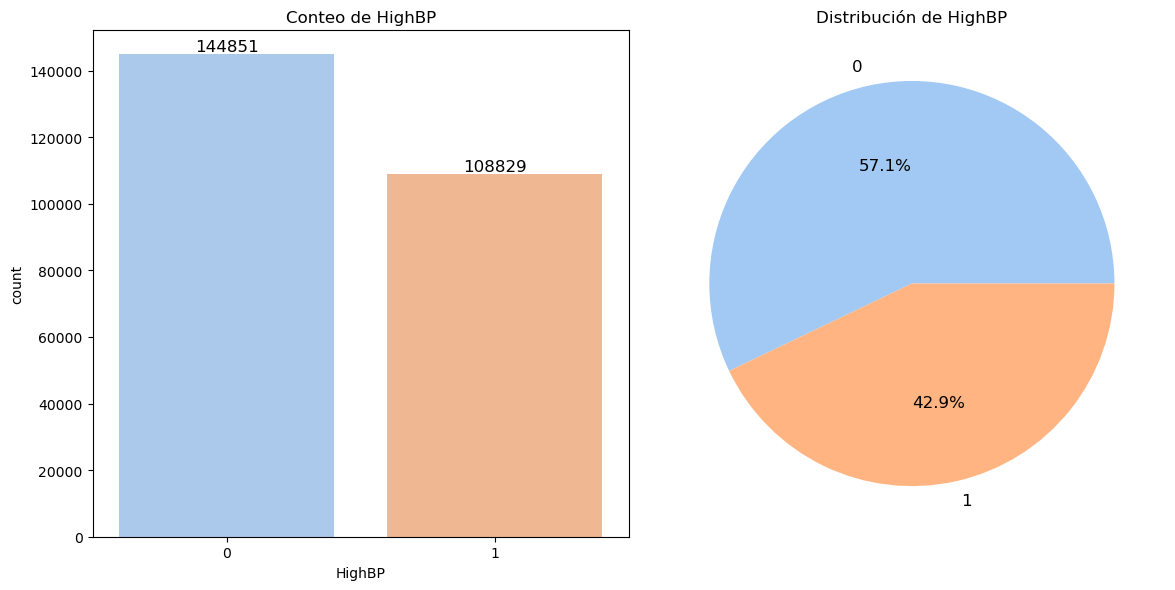


=== HIGHCHOL ===


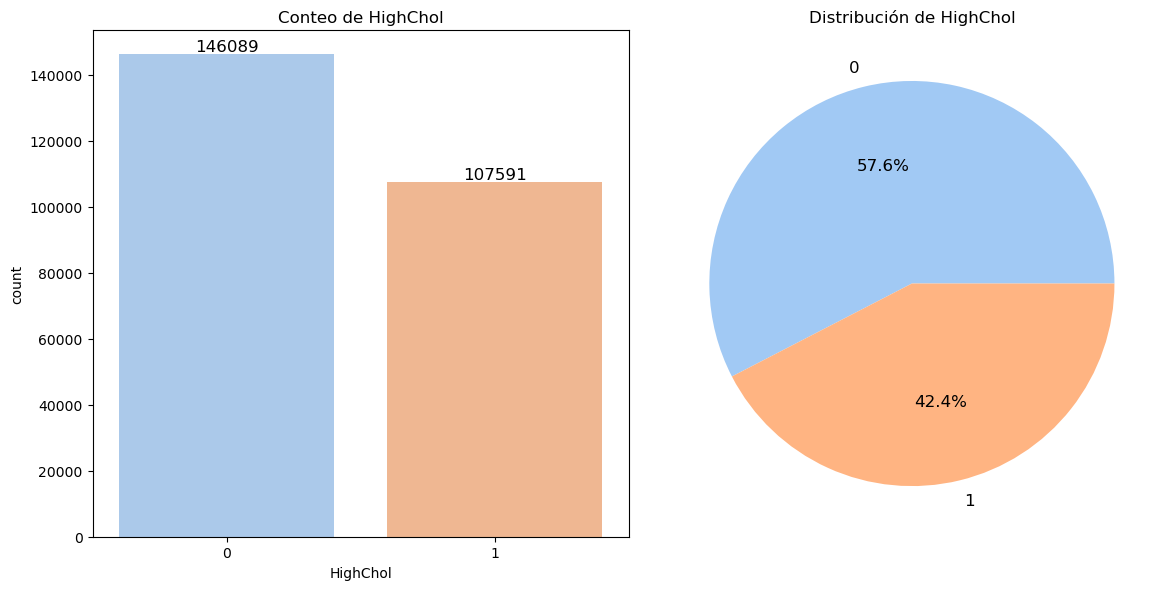


=== CHOLCHECK ===


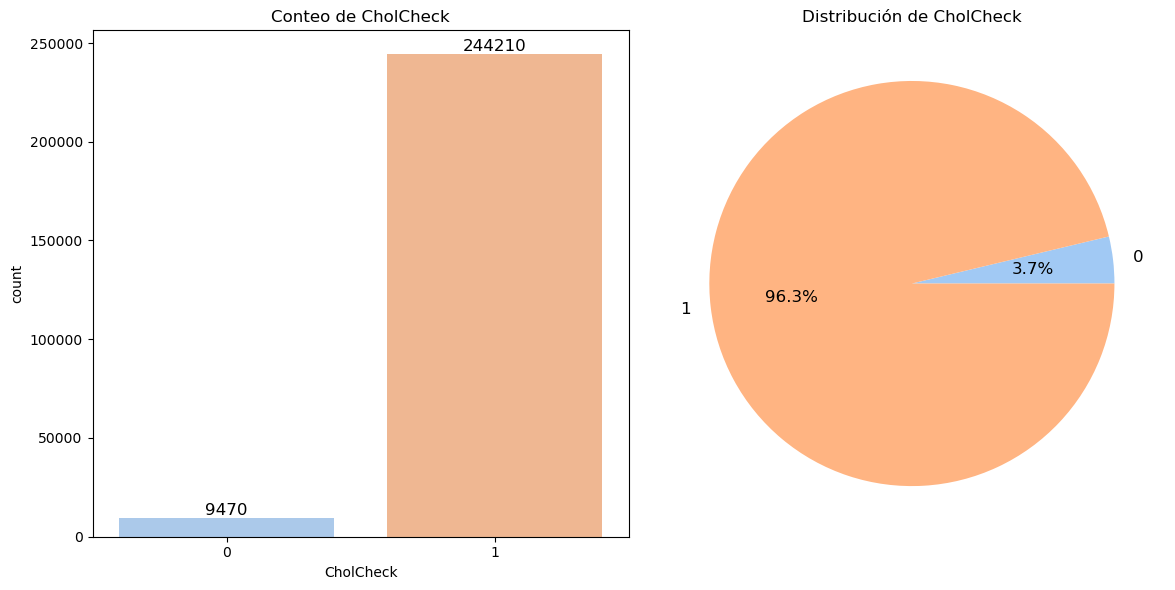


=== SMOKER ===


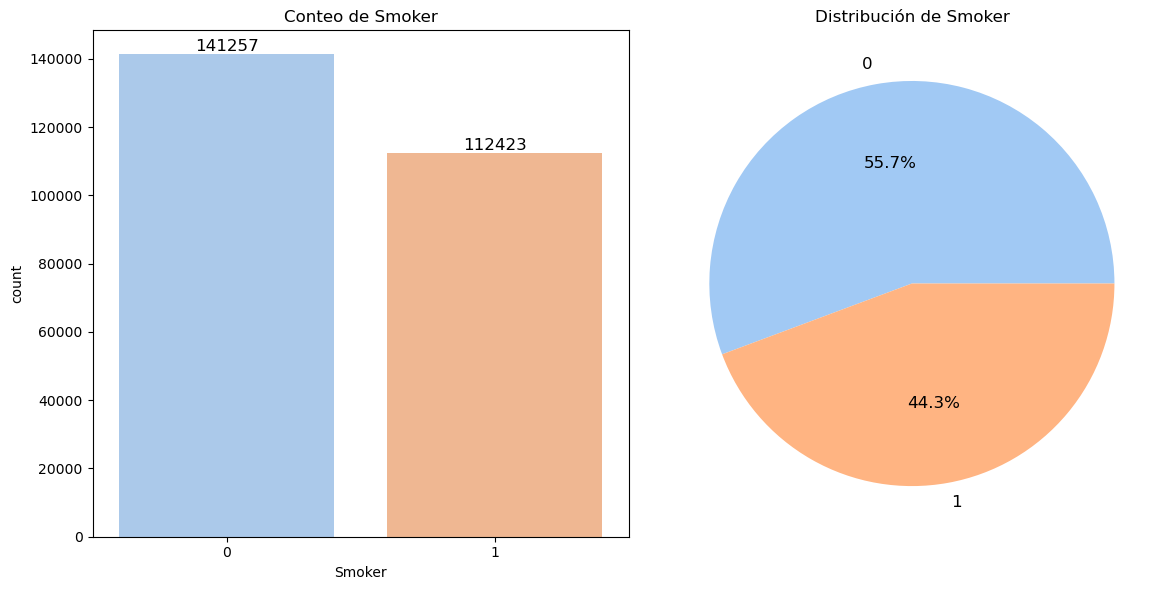


=== STROKE ===


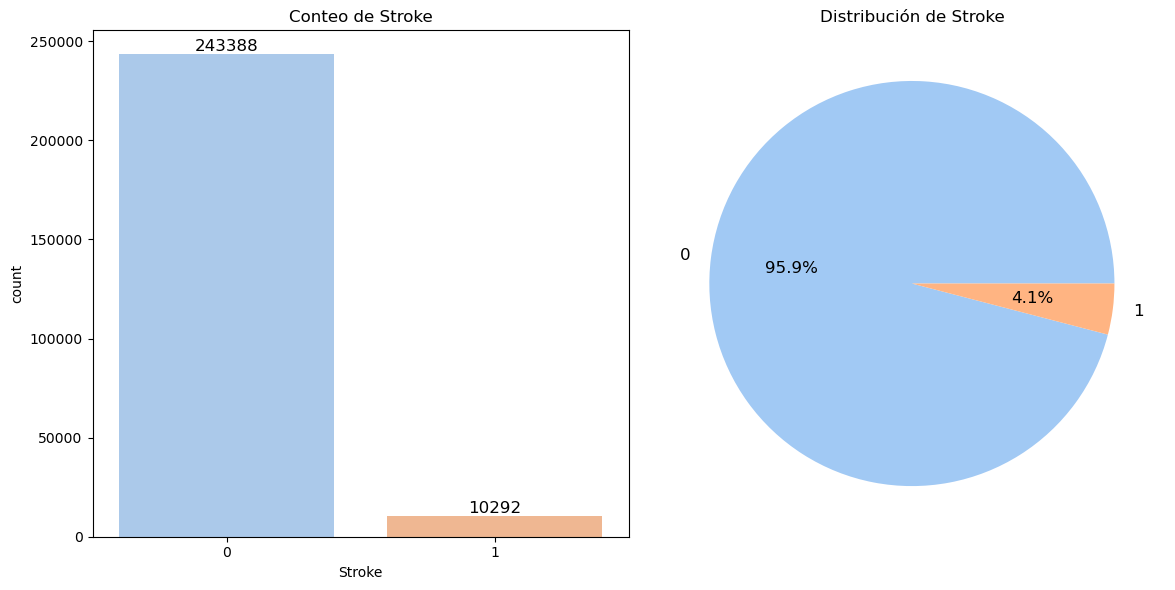


=== HEARTDISEASEORATTACK ===


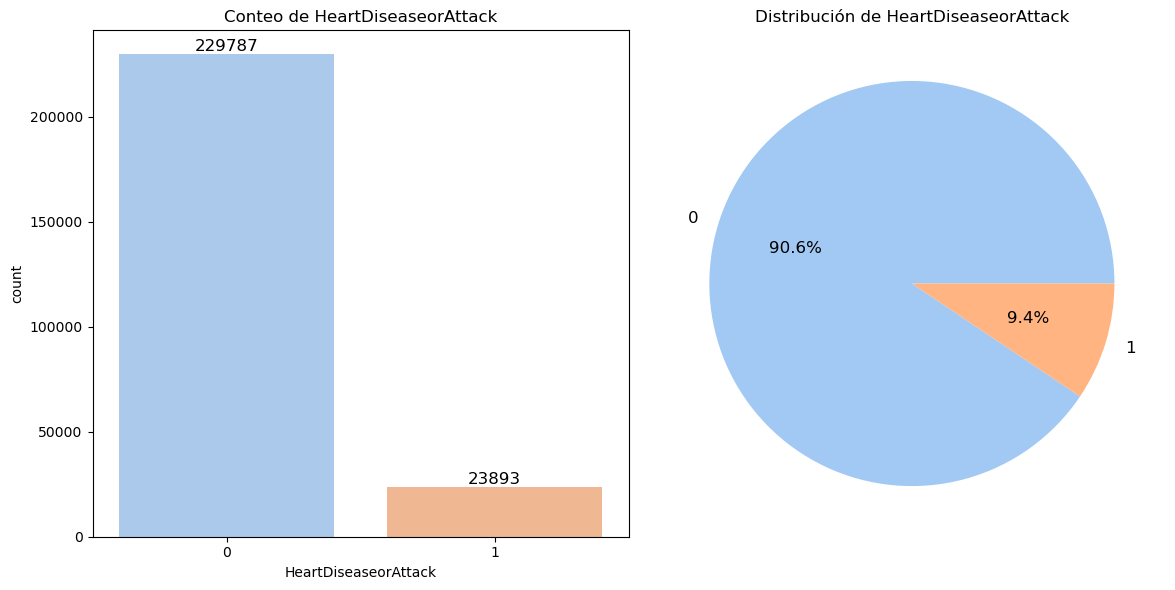


=== PHYSACTIVITY ===


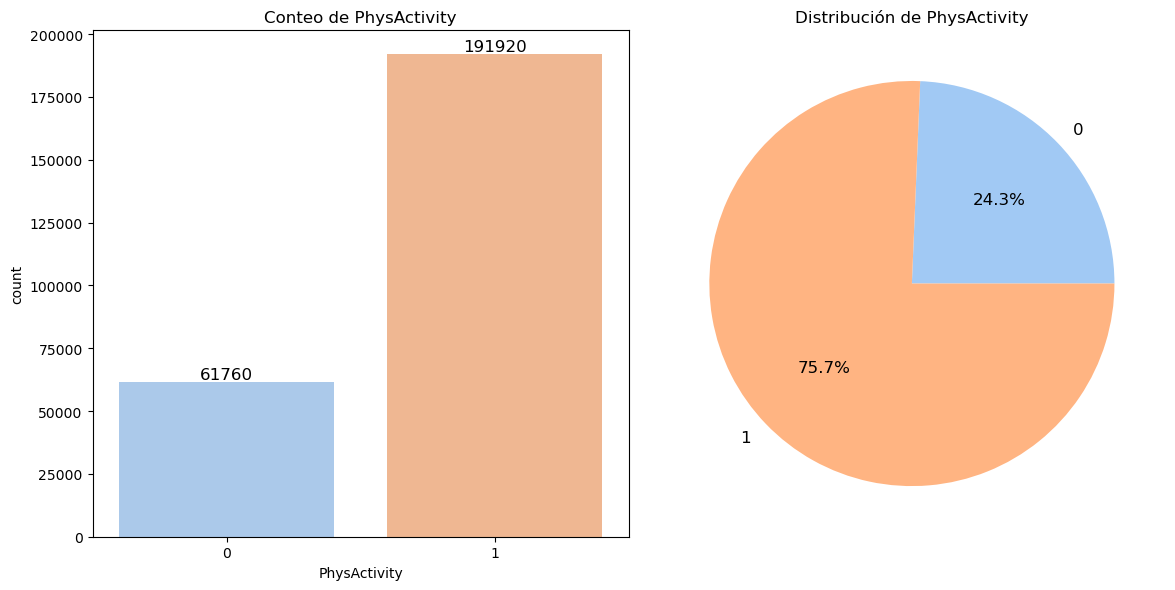


=== FRUITS ===


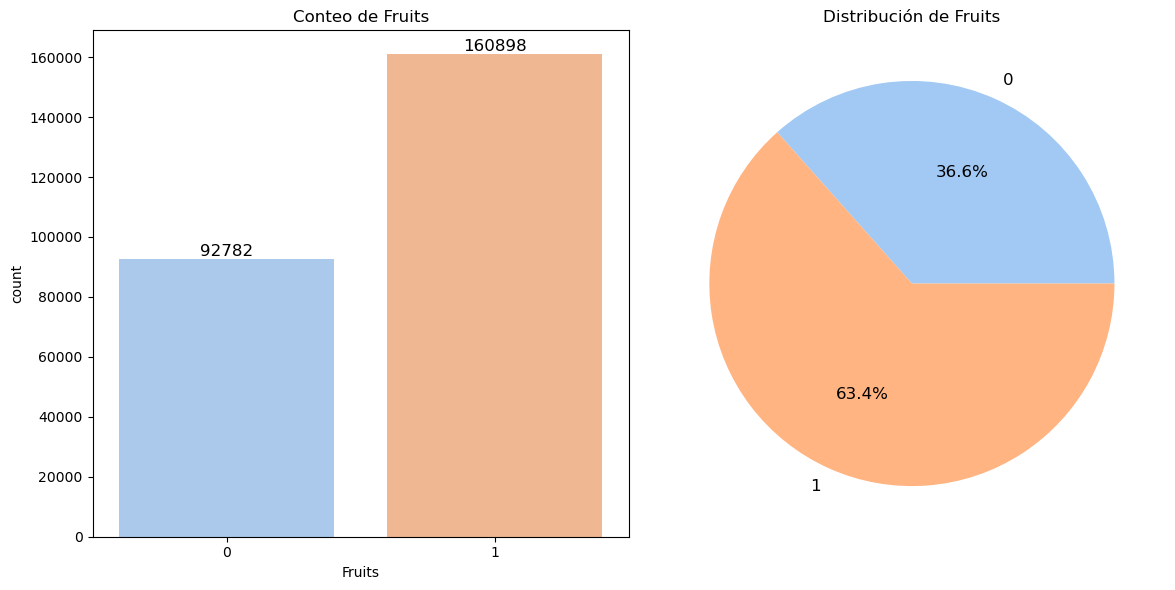


=== VEGGIES ===


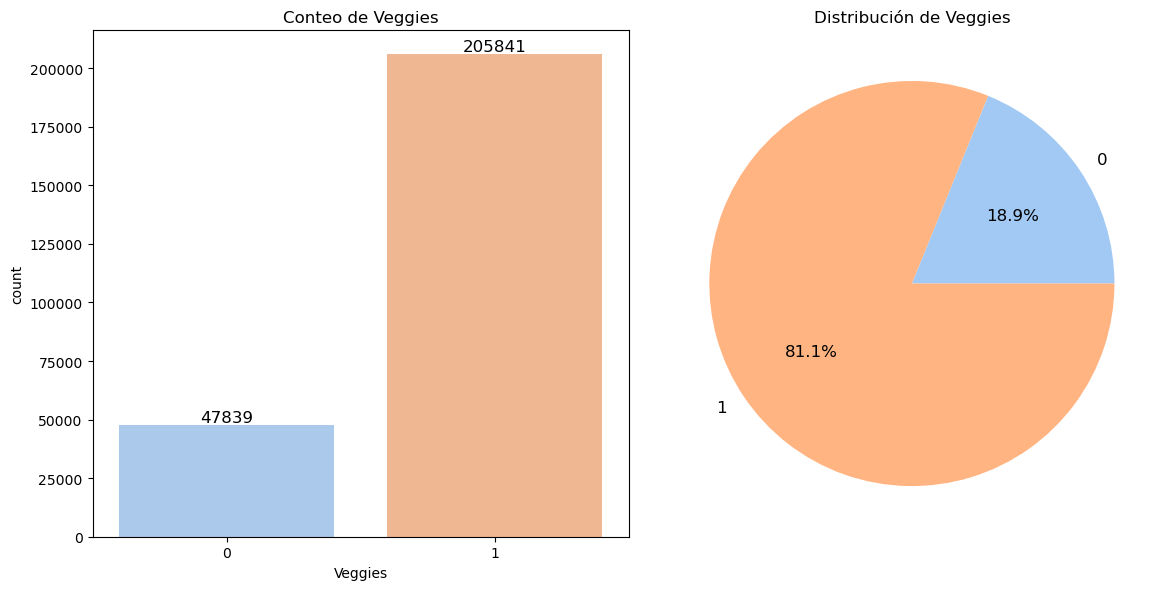


=== HVYALCOHOLCONSUMP ===


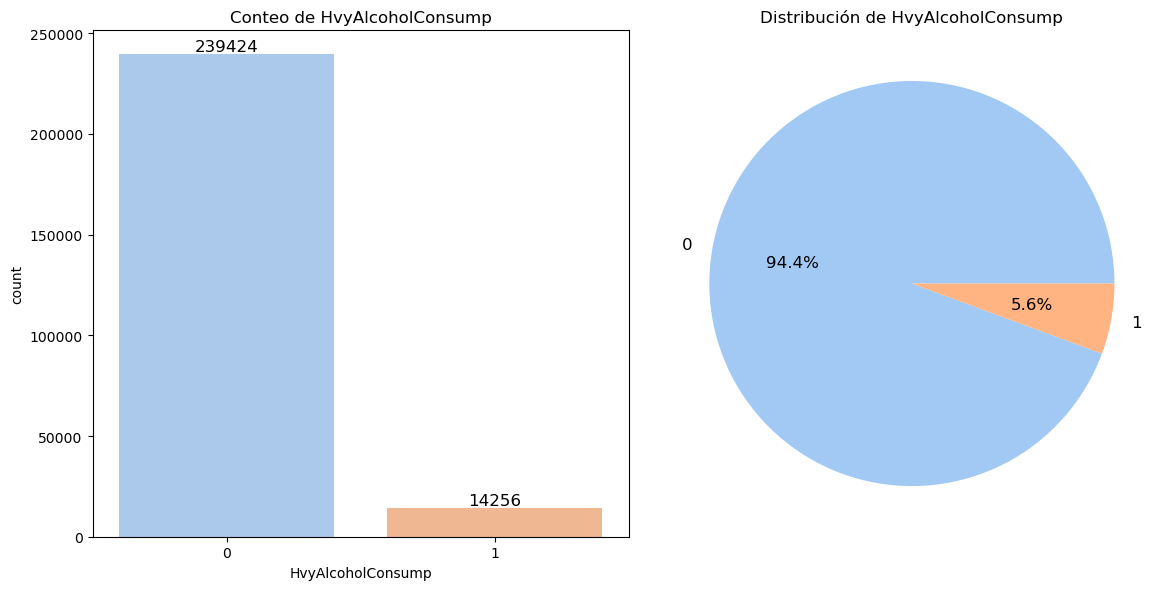


=== ANYHEALTHCARE ===


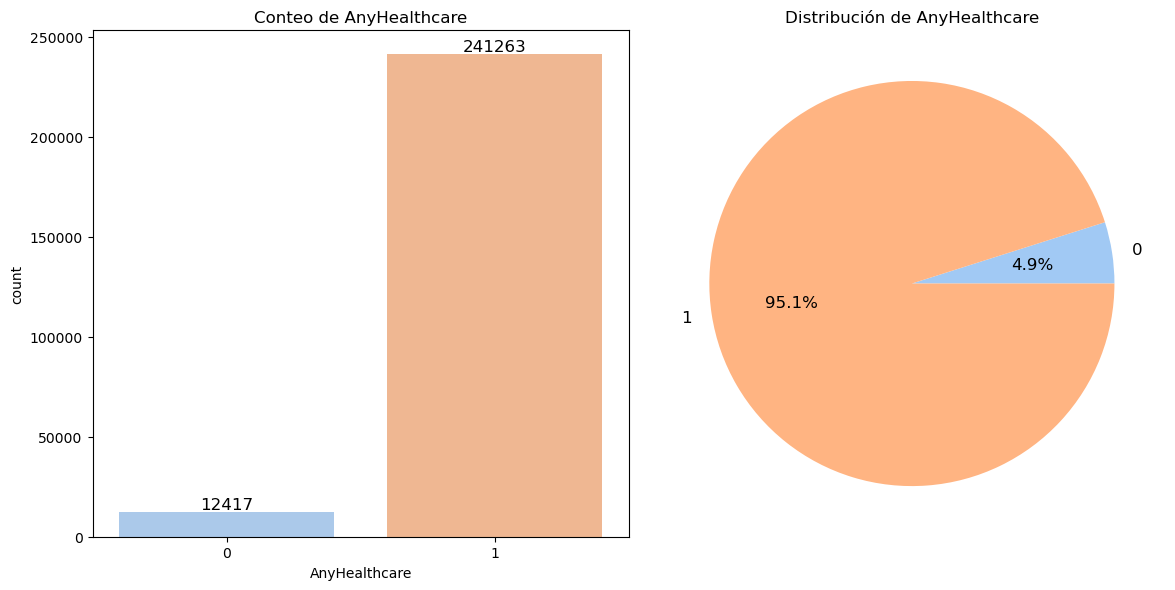


=== NODOCBCCOST ===


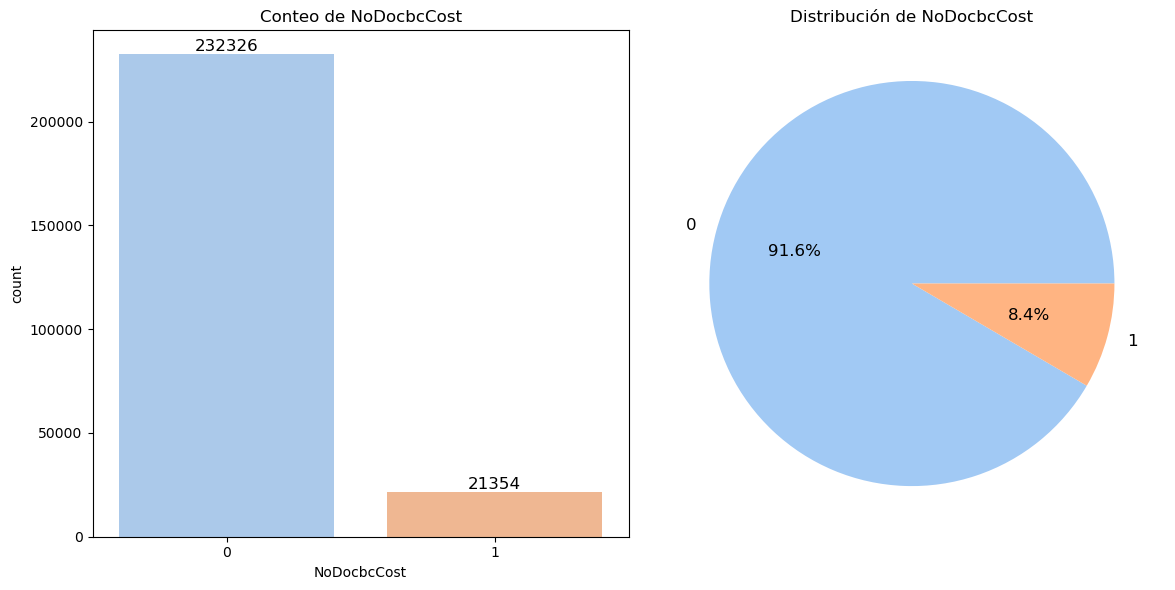


=== DIFFWALK ===


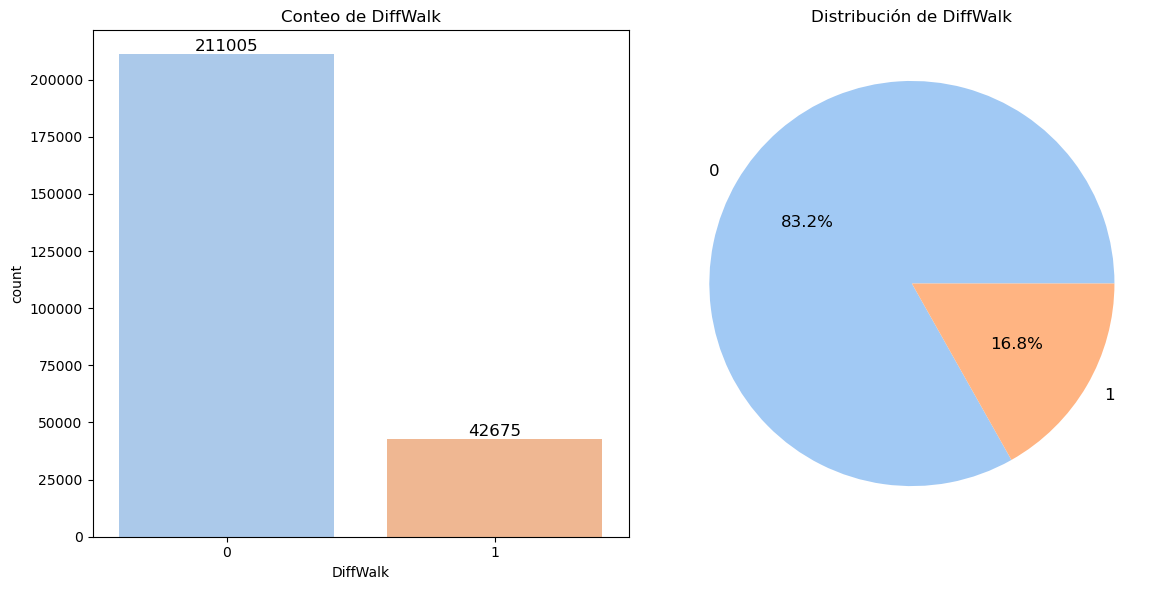


=== SEX ===


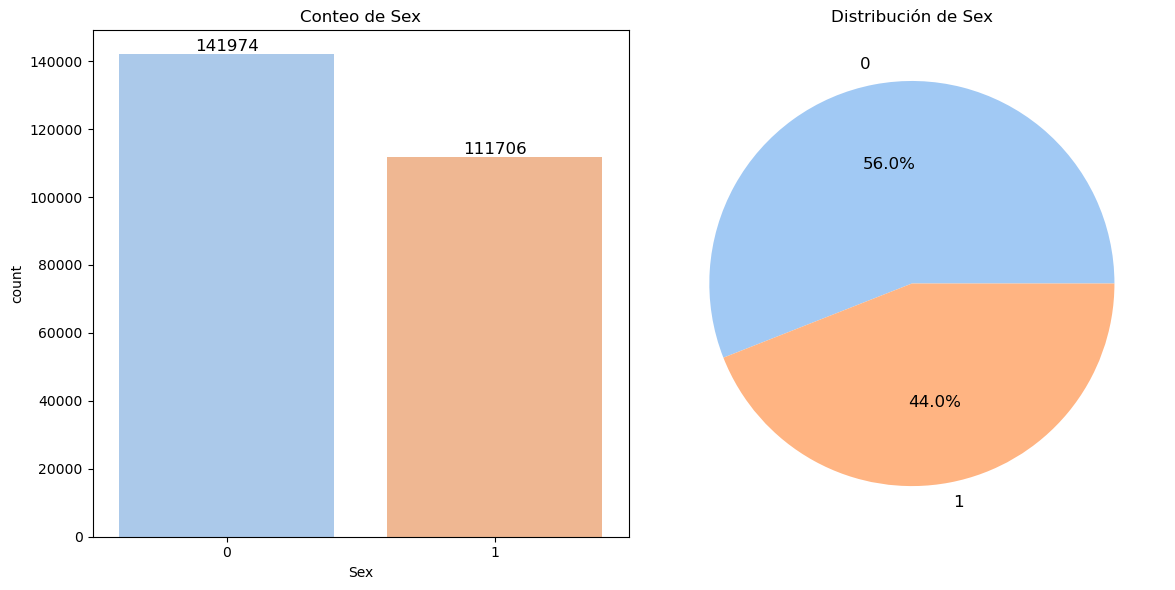


=== DIABETES_BINARY ===


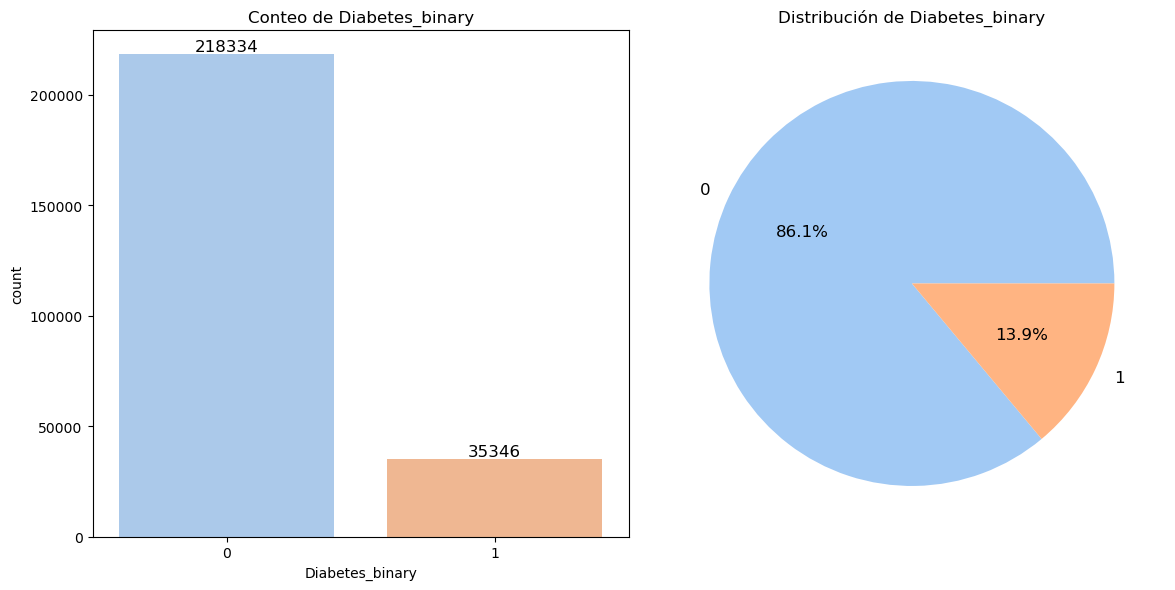

In [8]:
binarias = [col for col in df.columns if df[col].nunique() == 2]

for col in binarias:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    # Definir el orden y los colores consistentes
    value_order = sorted(df[col].unique())
    colors = sns.color_palette('pastel')  # Misma paleta para ambos gráficos
    
    # Primer subplot - Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    # Añadir los valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=0, fontsize=12)
    
    # Segundo subplot - Diagrama de torta
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order]  # Ordenar los conteos
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors, textprops={'fontsize': 12} )  # Usar la misma paleta ordenada
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

El análisis de las proporciones revela un marcado desbalance en varias variables binarias, lo que tiene implicaciones importantes para el análisis y modelado:

- **Variables con Distribución Relativamente Equilibrada**: Algunas características como `HighBP` (42.9% positivos) y `HighChol` (42.4% positivos) presentan una distribución cercana al equilibrio, lo que facilita su análisis sin necesidad de ajustes especiales. Esto sugiere que estas condiciones son comunes en la población estudiada, lo que podría reflejar factores de riesgo prevalentes en el perfil demográfico de la muestra.

- **Desbalance Moderado**: Variables como `Fruits` (36.6% negativos) y `Veggies` (18.9% negativos) muestran un desbalance moderado. Aunque no son extremos, estos casos podrían beneficiarse de técnicas en modelos predictivos para asegurar que la clase minoritaria tenga suficiente representación en las predicciones.

- **Desbalance Extremo**: En contraste, variables como `Stroke` (4.1% positivos), `HvyAlcoholConsump` (5.6% positivos) e incluso la variable objetivo `Diabetes_binary` presentan un desbalance pronunciado, donde la clase positiva es significativamente menor. Esto implica riesgos como:

    - **Sesgo en Modelos**: Los algoritmos podrían ignorar la clase minoritaria al optimizar la precisión global, subestimando patrones críticos.
    - **Sobreajuste**: Con tan pocos casos positivos, el modelo podría memorizar ruido en lugar de aprender relaciones generalizables.

### **Variables Categóricas**

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. 

**Cada gráfico muestra**:

- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas en su escala natural.


=== GENHLTH ===


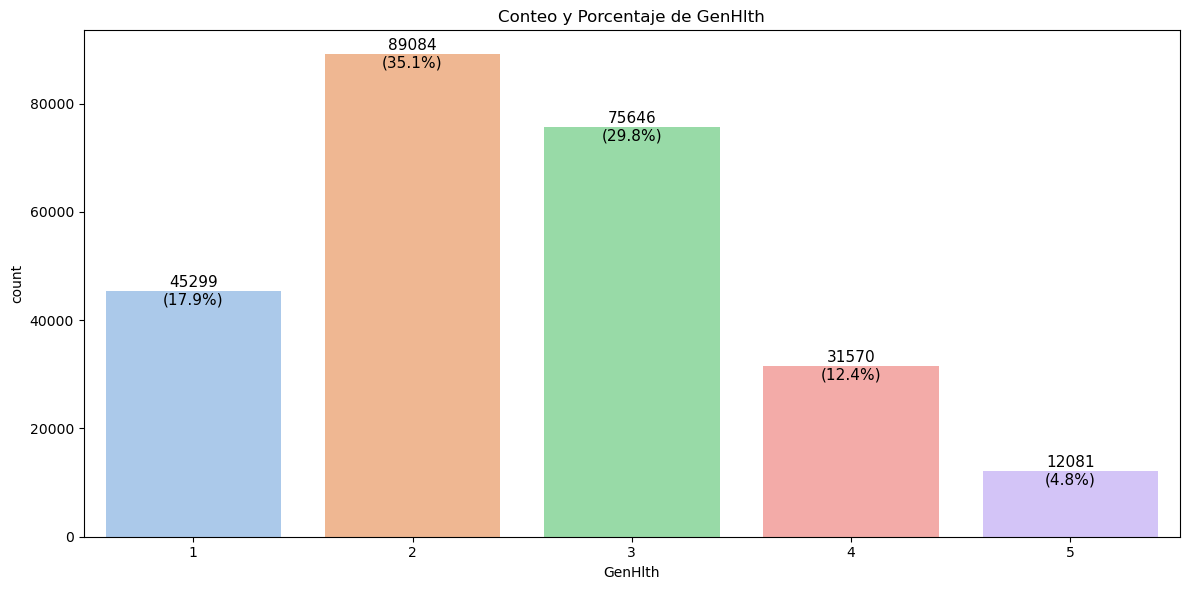


=== AGE ===


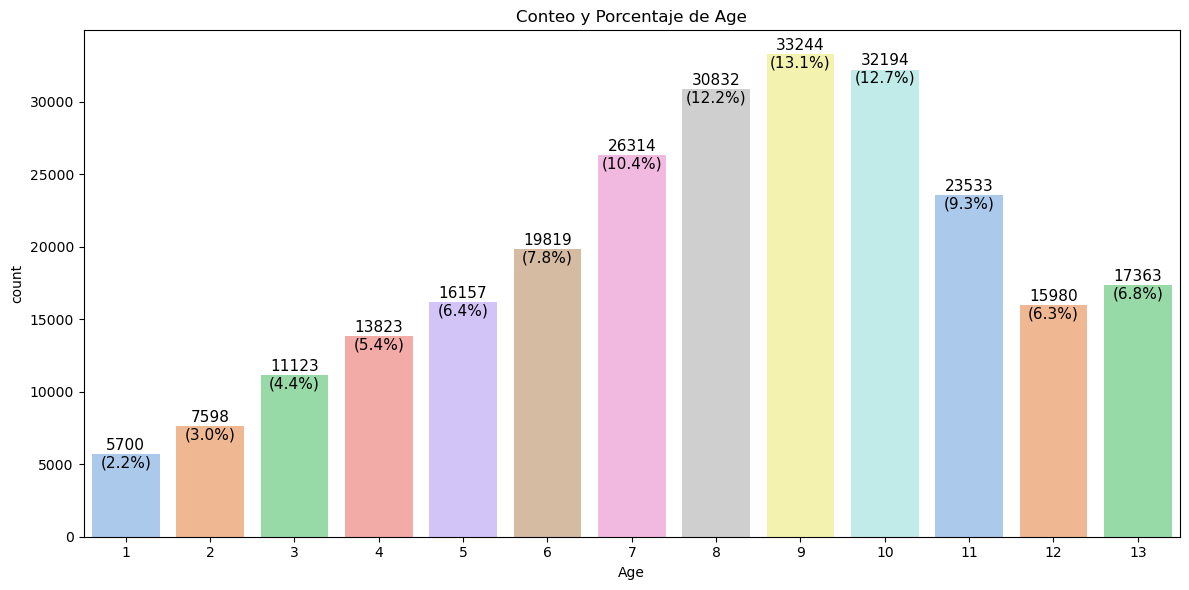


=== EDUCATION ===


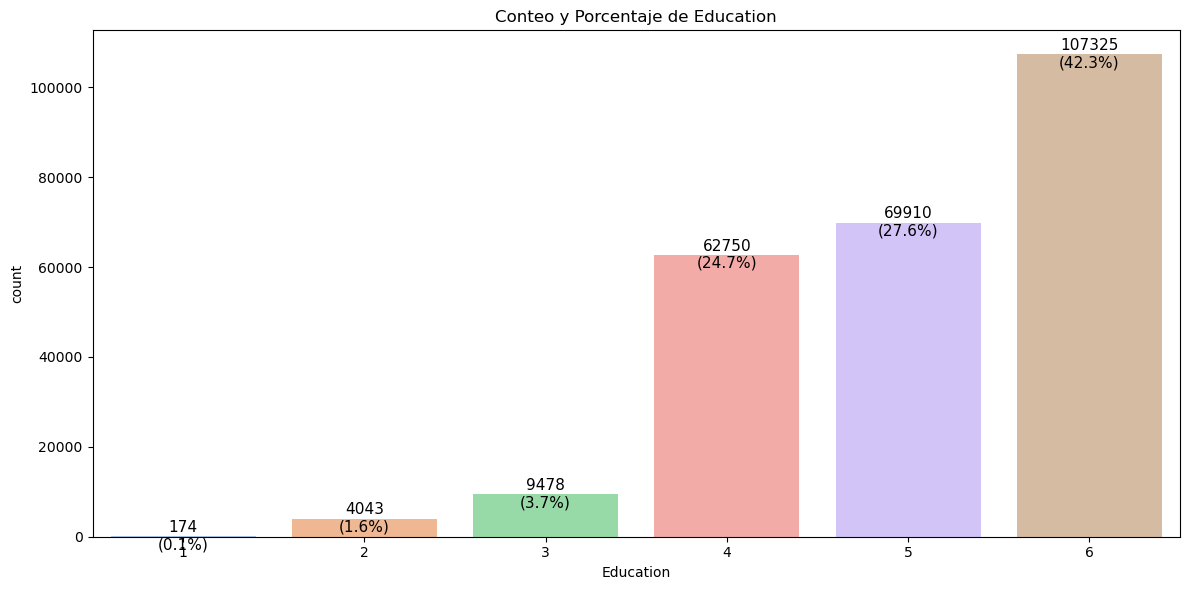


=== INCOME ===


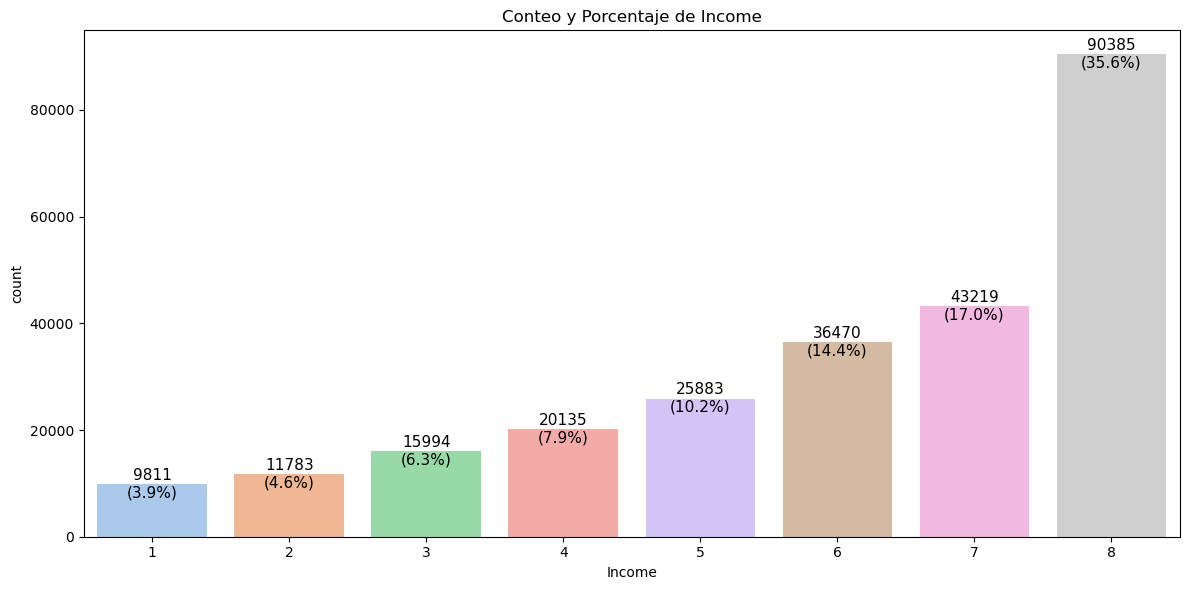

In [9]:
categoricas = ['GenHlth', 'Age', 'Education', 'Income']

for col in categoricas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    # Obtener el orden de las categorías según el diccionario
    value_order = sorted(df[col].unique())  
    
    ax = sns.countplot(x=df[col], order=value_order, palette='pastel')
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 0),
                    textcoords='offset points',
                    fontsize=11)
    plt.title(f'Conteo y Porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()
  

El análisis de las distribuciones revela patrones demográficos y socioeconómicos claves en la población estudiada:

- `GenHlth`
La distribución muestra una tendencia hacia percepciones positivas de salud: el 53.0% de los encuestados reporta salud "muy buena" (35.1%) o "excelente" (17.9%), mientras solo el 4.8% la califica como "pobre".

- `Age`
 Se observa una concentración alta en edades entre 50 y 69 años (grupos 7 a 10), lo cual sugiere que la mayoría de los participantes o casos en este conjunto de datos son personas de mediana edad a adultos mayores. Los grupos con menor representación son:
    - **18–24 años (grupo 1)**: 5,700 personas (2.2%).
    - **25–29 años (grupo 2)**: 7,598 personas (3.0%).
Esto indica que hay menos jóvenes en el conjunto de datos, posiblemente porque se trata de una muestra relacionada con condiciones de salud que afectan más a personas mayores.

-  `Education`
Se observa una marcada sobrerrepresentación de educación superior: el 42.3% corresponde a graduados universitarios (categoría 6), seguido por "algo de universidad" (27.6%). Esto se evidencia al compararlo con el 0.1%, 1.6% y 3.7% de las categorias 1, 2 y 3 respectivamente. Este perfil sugiere un sesgo de selección hacia población con mayor acceso a educación, lo que podría limitar la generalización de hallazgos a grupos menos educados.

- `Income`
La distribución económica muestra una concentración en la clase media-alta: el 35.6% pertenece a la categoría más alta, seguido por la segunda categoría mas alta con 17%. Esta estructura, combinada con los datos educativos, refuerza la hipótesis de que la muestra subrepresenta poblaciones vulnerables.

### **Variables Númericas**

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [10]:
numericas = ['MentHlth', 'PhysHlth', 'BMI']
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0


- `MentHlth`: Los participantes reportaron un promedio de 3 días con salud mental afectada en los últimos 30 días. Con una desviación estándar de 7 días, indicando una variabilidad moderada en las respuestas.
- `PhysHlth`: El promedio fue ligeramente mayor (4 días), sugiriendo que los problemas físicos son más frecuentes que los mentales en esta muestra. Con una dispersión mayor (desviación estándar de 9 días), lo que sugiere que los problemas físicos muestran mayor variabilidad entre los individuos.

Ambas variables comparten un patrón similar en los percentiles:
- **25% inferior**: 0 días de afectación.
- **Mediana (50%)**: 0 días.
- **75% superior**: 2 días para salud mental y 3 días para salud física.

Este patrón revela que la mayoría de la población (al menos 50%) no reportó días con problemas de salud.

- `BMI`: El índice de Masa Corporal muestra una media de 28.38 y una desviación estándar de 6.61, indicando que la mayoría de los valores se agrupan alrededor de 28.38, con una dispersión moderada. La distribución está sesgada hacia valores más altos.
    - **Mediana (50%)**: 27.0 < Media (28.38), lo que sugiere una cola derecha (presencia de valores atípicos altos).
    - **Rango intercuartílico (IQR)**: 7.0 (Q3-Q1 = 31.0 - 24.0), capturando el 50% central de los datos.
    - **Valores extremos**: El mínimo (12.0) y máximo (98.0) son atípicos, especialmente el máximo (98.0), que está muy alejado del percentil 75% (31.0).

---

También, se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.


=== MENTHLTH ===
Skew: 2.72
Kurtosis:  6.44
Coeficiente de Variación:  232.76 %


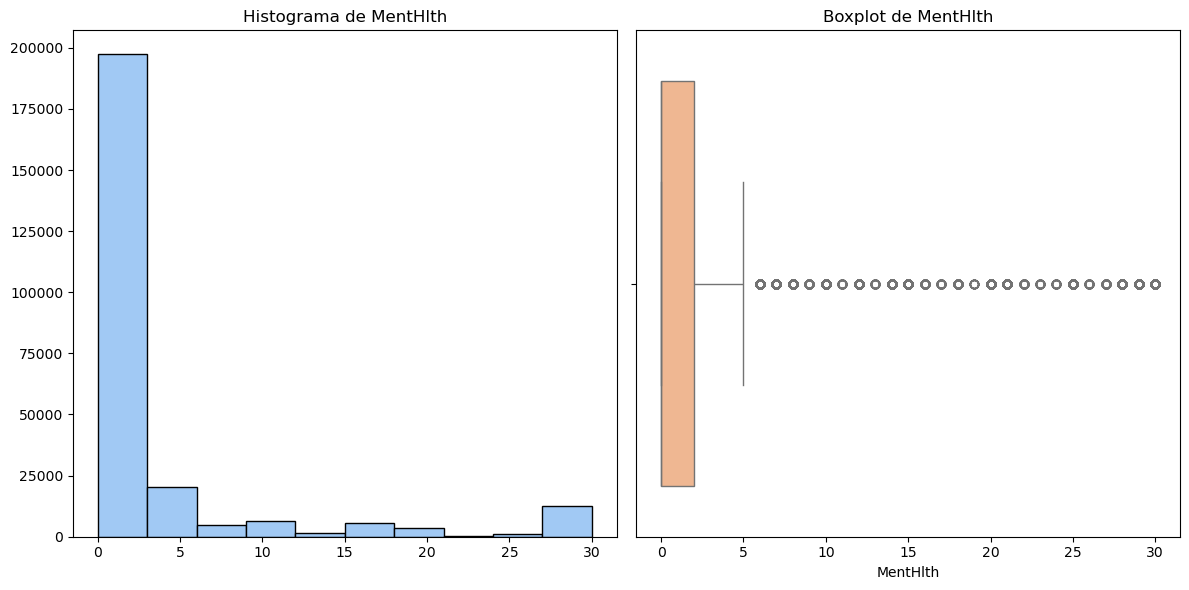


=== PHYSHLTH ===
Skew: 2.21
Kurtosis:  3.5
Coeficiente de Variación:  205.51 %


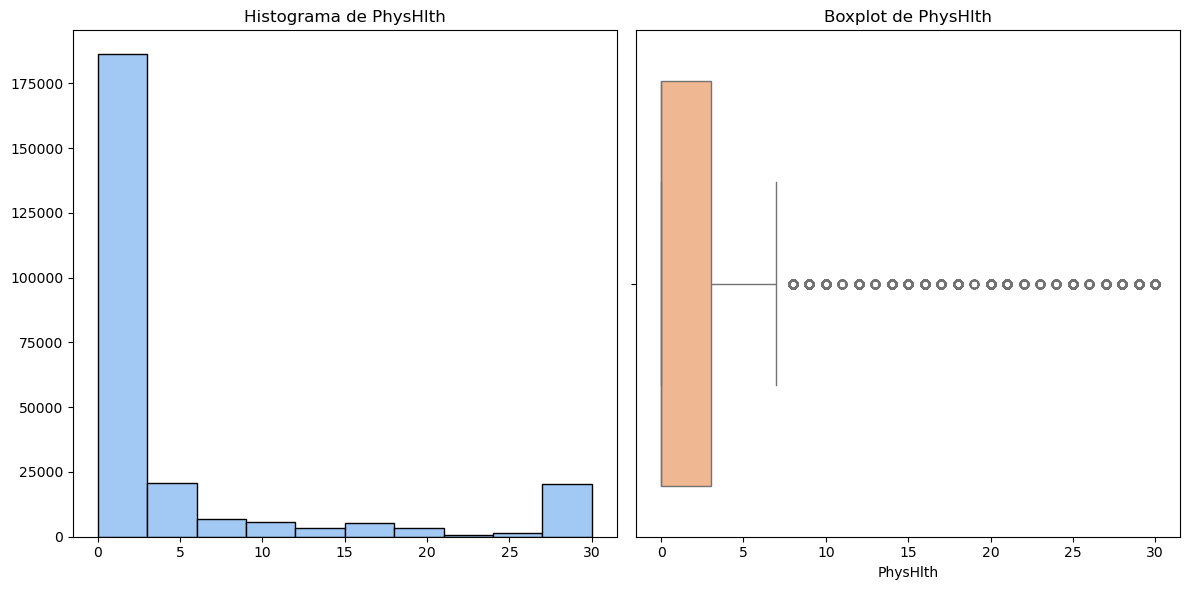


=== BMI ===
Skew: 2.12
Kurtosis:  11.0
Coeficiente de Variación:  23.28 %


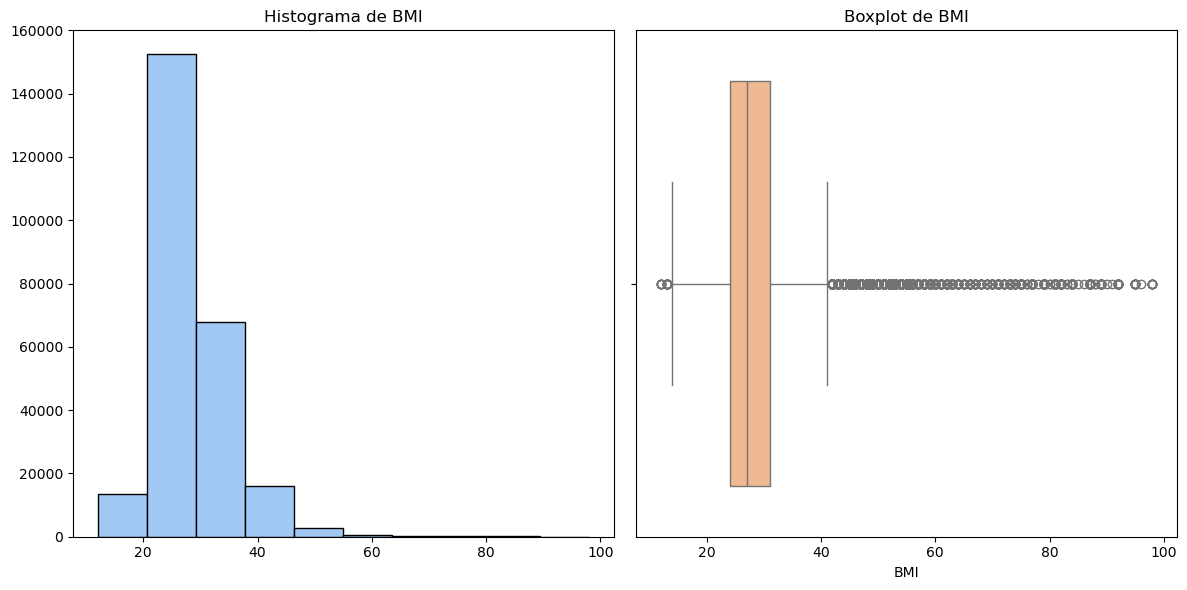

In [11]:
for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    
    plt.subplot(1, 2, 1)
    plt.hist(df[col], edgecolor="black", color=colors[0])
    plt.title(f'Histograma de {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color=colors[1])
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

Los datos muestran que la variable `MentHlth` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.72) con una kurtosis elevada (6.44), indicando:
- Una concentración extrema de valores bajos (cerca de 0 días).
- Una larga cola hacia valores altos.
- Presencia significativa de outliers, como evidencia el boxplot.
- Alta variabilidad relativa (Coeficiente de Variación = 232.76%), confirmando la fuerte dispersión entre los valores bajos predominantes y los valores altos extremos.

Esta distribución sugiere que la mayoría de la población reporta pocos o ningún día de afectación mental, mientras que un pequeño grupo muestra afectación persistente.

La variable `PhysHlth` también muestra sesgo positivo (skewness = 2.21) pero con una kurtosis menos pronunciada (3.5), lo que revela:
- Similar concentración en valores bajos.
- Cola derecha menos extrema que MentHlth.
- Menor cantidad de outliers extremos.
- Alta variabilidad relativa (Coeficiente de Variación = 205.51%), aunque ligeramente menor que MentHlth, confirmando una dispersión significativa entre los valores bajos predominantes y los valores altos.

Esta distribución indica que la mayoría de la población reporta buena salud física, pero existe un grupo con afectación física persistente, aunque menos extremo que en el caso de la salud mental.

Los datos muestran que la variable `BMI` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.12) con una kurtosis muy elevada (11.0), lo que indica:
- Una concentración extrema de valores en el rango bajo a moderado (probablemente entre 20-30).
- Una cola derecha muy larga que se extiende hacia valores altos de BMI.
- Presencia significativa de outliers extremos en los valores superiores.
- Baja variabilidad relativa (Coeficiente de Variación = 23.28%), sugiriendo que aunque existen valores extremos, la mayoría de los datos se agrupan de manera más compacta alrededor de la media en comparación con las variables de salud.

Esta distribución revela que mientras la mayoría de la población tiene un BMI normal o con sobrepeso moderado, existe un grupo con obesidad severa cuyos valores son atípicos pero relevantes para el análisis.

Comparado con `MentHlth` y `PhysHlth`:
- El sesgo es similar pero ligeramente menos pronunciado.
- La kurtosis es notablemente más alta, mostrando mayor concentración en valores centrales.
- Los outliers parecen ser más extremos en BMI que en las variables de salud mental/física, debido a que en las variables de percepción el rango va desde 0 a 30 días del mes, en cambio el BMI no tiene limite.


#### **Análisis de Valores Atípicos en BMI**

Para la identificación de valores atípicos en la variable `BMI`, se aplicó el método del rango intercuartílico (IQR). 

In [12]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['BMI'] < limite_inferior) | (df['BMI'] > limite_superior)]
print(f"Número de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")

Número de outliers: 9847
Porcentaje de outliers: 3.88%


Para el tratamiento de valores atípicos en la variable `BMI`, se aplicó la técnica de winsorización al 1% exclusivamente en el extremo superior de la distribución. Esta decisión se basó en:

- **Preservar la integridad de la muestra** manteniendo todos los registros.
- **Minimizar la influencia de valores extremos** en el rango de obesidad severa.
- **Conservar los valores de bajo peso** según tablas médicas establecidas, ya que la winsorización en el límite inferior habría eliminado casos válidos de delgadez severa que son clínicamente relevantes.

**El nivel del 1% se seleccionó considerando:**
- El análisis previo que identificó 3.88% de valores atípicos.
- La marcada asimetría de la distribución, donde los valores atípicos superiores (obesidad mórbida) mostraban mayor dispersión y valores más extremos que los inferiores.
- El criterio clínico que prioriza mantener los rangos válidos de bajo peso según tablas médicas establecidas, mientras se controlan los valores de obesidad extrema que podrían sesgar el modelo.

In [13]:
df['BMI'] = winsorize(df['BMI'], limits=[0, 0.01])

Se verifican los cambios realizados.

In [14]:
df['BMI'].describe()

count    253680.000000
mean         28.277681
std           6.049009
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          50.000000
Name: BMI, dtype: float64

**Reducción de la desviación estándar**
   - De 6.61 a 6.05 (-8.5%).
   - Indica menor dispersión y datos más homogéneos, pero manteniendo variabilidad.

**Rango corregido**
   - Mínimo: Se mantuvo en 12.0 (se preservaron valores bajos clínicamente relevantes).
   - Máximo: De 98.0 a 50.0 (dentro de rangos médicos realistas).
   - Se conservaron casos de bajo peso que podrían ser clínicamente válidos según la literatura.

**Media ajustada**
   - De 28.38 a 28.28 (-0.10 puntos).
   - Cambio mínimo, lo que indica que la distribución central se mantuvo intacta.

**Lo que se mantuvo estable:**
- **Mediana (50%):** 27.0 → 27.0 (sin cambios).
- **Primer cuartil (25%):** 24.0 → 24.0 (sin cambios).  
- **Tercer cuartil (75%):** 31.0 → 31.0 (sin cambios).
- **Tamaño de muestra:** 253,680 → 253,680 (preservado).

**La winsorización superior al 1% fue exitosa porque:**
- Eliminó valores extremos clínicamente improbables en el extremo superior (BMI 98).
- Preservó valores bajos que pueden representar casos reales de bajo peso o desnutrición.
- Preservó completamente la distribución central (cuartiles idénticos).
- Mantuvo el tamaño de la muestra original.
- Redujo la varianza sin distorsionar la tendencia central.
- Los nuevos límites superiores (50) están dentro de rangos médicamente posibles mientras se conserva la variabilidad natural en valores bajos.

#### **Verificación Visual del Efecto de la Winsorization**

Para evaluar visualmente el impacto de la winsorization en la distribución y dispersión de la variable tratada, se generaron histogramas y diagramas de caja (boxplots). Estas visualizaciones permiten contrastar las distribuciones antes y después del tratamiento, confirmando la reducción de valores extremos mientras se mantiene la estructura central de los datos, asegurando así la preparación adecuada para el modelado. Además se evalua nuevamente:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.


=== BMI ===
Skew: 1.06
Kurtosis:  1.48
Coeficiente de Variación:  21.39 %


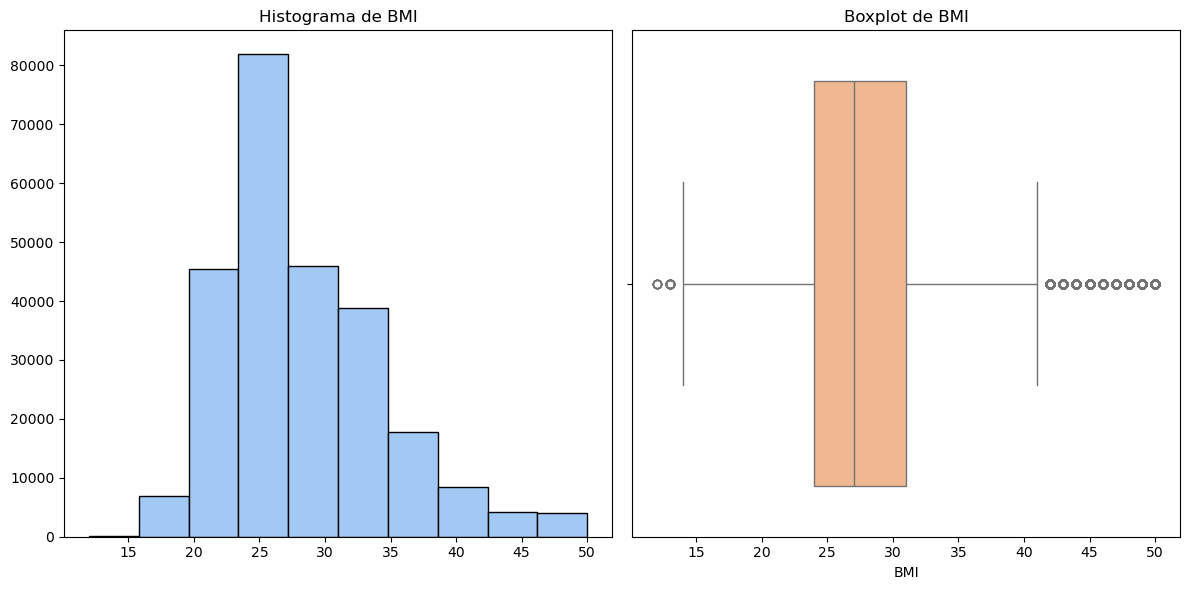

In [15]:
print(f"\n=== {col.upper()} ===")

plt.figure(figsize=(12, 6))

print('Skew:', round(df['BMI'].skew(), 2))
print('Kurtosis: ', round(df['BMI'].kurtosis(), 2))
coef_variacion = (df['BMI'].std()/ df['BMI'].mean() ) * 100
print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')

plt.subplot(1, 2, 1)
plt.hist(df[col], edgecolor="black", color=colors[0])
plt.title(f'Histograma de {col}')
    
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color=colors[1])
plt.title(f'Boxplot de {col}')
    
plt.tight_layout()
plt.show()

**Reducción de asimetría (Skewness)**
- De 2.12 a 1.06 (-50% de reducción).
- Interpretación: La distribución era altamente sesgada a la derecha (valores extremos altos) y ahora tiene un sesgo moderado.
- Significado: Los valores extremos hacia la derecha (BMI altos) fueron tratados efectivamente, pero se preservó mayor asimetría natural al mantener los valores bajos intactos.

**Mejora en curtosis (Kurtosis)**
- De 11.0 a 1.48 (-86.5% de reducción).
- Interpretación: Pasó de una distribución extremadamente leptocúrtica (pico muy agudo y colas pesadas) a una distribución ligeramente leptocúrtica.
- Significado: Las colas extremadamente pesadas fueron eliminadas en su mayoría, pero se mantuvo cierta curtosis al preservar la variabilidad natural en el extremo inferior.

**Reducción controlada de variabilidad relativa**
- Coeficiente de Variación: De 23.28% a 21.39% (-8.1% de reducción).
- Interpretación: La dispersión relativa disminuyó ligeramente de forma controlada.
- Significado: La winsorización redujo la influencia de los valores extremos superiores sin comprometer la variabilidad natural de la variable, manteniendo una dispersión adecuada para análisis estadísticos.

**Comparación con una distribución normal**
- **Skewness ideal**: 0 (perfectamente simétrica).
- **Kurtosis ideal**: 0 (mesocúrtica, como la normal).
- **Nuevos valores**: 1.06 (skew) y 1.48 (kurtosis) → Más cercanos a la normalidad que el original, pero con mayor preservación de la distribución natural.

**La winsorización superior al 1% fue exitosa porque**
- Transformó una distribución altamente no-normal en una moderadamente no-normal.
- Preservó la variabilidad natural en valores bajos que pueden ser clínicamente relevantes.
- Eliminó los valores extremos superiores que causaban las colas pesadas.
- Redujo la variabilidad de forma controlada sin sobre-ajustar la distribución.
- Mejoró significativamente las propiedades estadísticas para modelamiento manteniendo mayor autenticidad en la distribución.

La variable BMI ahora es adecuada para: Modelos que requieren menor influencia de outliers extremos, mientras se preserva la información clínica potencialmente valiosa en el rango inferior y se mantiene una dispersión realista del índice de masa corporal.

## **Análisis Bivariado**
El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

### **Variables Binarias vs Diabetes**

Se generan graficos de barras para analizar la relación entre el conjunto de variables binarias y la presencia de diabetes con el fin de identificar qué variables binarias están asociadas a mayores proporciones de diabetes en el conjunto de datos.

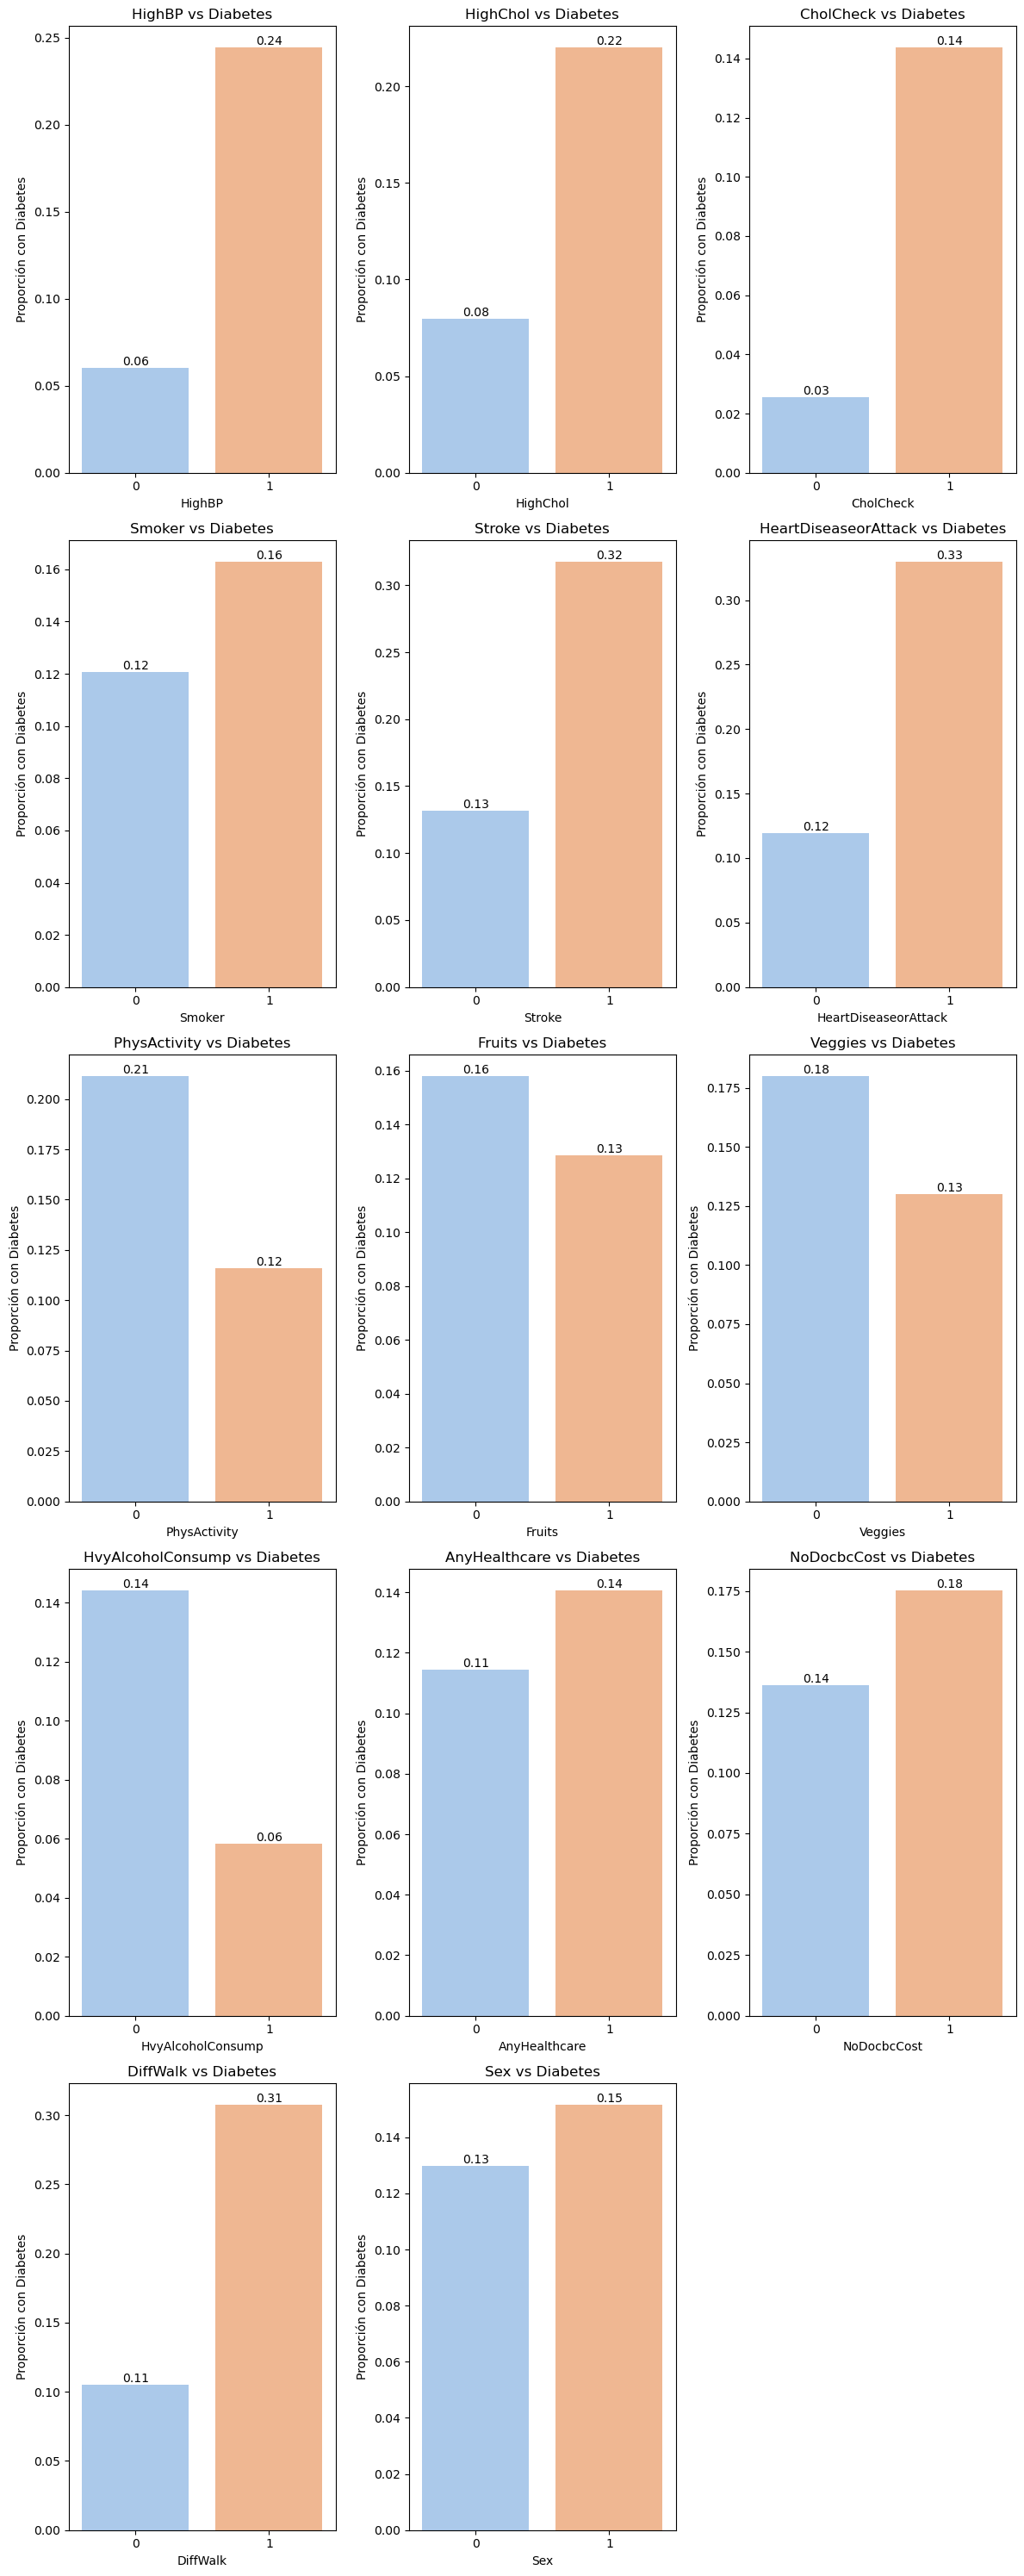

In [16]:
plt.figure(figsize=(12, 6 * 5))
for i, col in enumerate(binarias, 1):  
    if col != "Diabetes_binary":
        plt.subplot(5, 3, i) 
        ax = sns.barplot(
        x=col, 
        y='Diabetes_binary', 
        data=df, 
        palette='pastel',
        errorbar=None
        )
        plt.title(f'{col} vs Diabetes')
        plt.ylabel('Proporción con Diabetes')
        
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")  
    
plt.tight_layout()  
plt.show()



Los resultados visualizados muestran que la proporción de personas con diabetes es notablemente mayor en aquellos que presentan condiciones crónicas como hipertensión, colesterol alto, enfermedades cardiovasculares, antecedentes de derrame cerebral y dificultades físicas para caminar. Esta tendencia sugiere una fuerte asociación entre la diabetes y la presencia de otras enfermedades no transmisibles. 

Además, se observa que ciertos comportamientos y estilos de vida, como la inactividad física y el consumo de tabaco, también están relacionados con una mayor prevalencia de diabetes. Por otro lado, factores como la actividad física regular y una alimentación con frutas y verduras parecen asociarse con una menor proporción de personas con diabetes. 

Finalmente, las barreras económicas y el acceso limitado a servicios de salud también muestran una posible relación con una mayor proporción de casos, lo cual resalta la importancia del contexto socioeconómico en el manejo y prevención de esta enfermedad. En conjunto, los gráficos evidencian que la diabetes no solo está influenciada por condiciones médicas, sino también por determinantes sociales y conductuales de la salud.

### **Variables Categóricas vs Diabetes**

Se generan graficos de barras para analizar la relación entre variables categóricas y la presencia de diabetes en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de diabetes, lo que podría indicar posibles factores de riesgo asociados.


=== GENHLTH ===


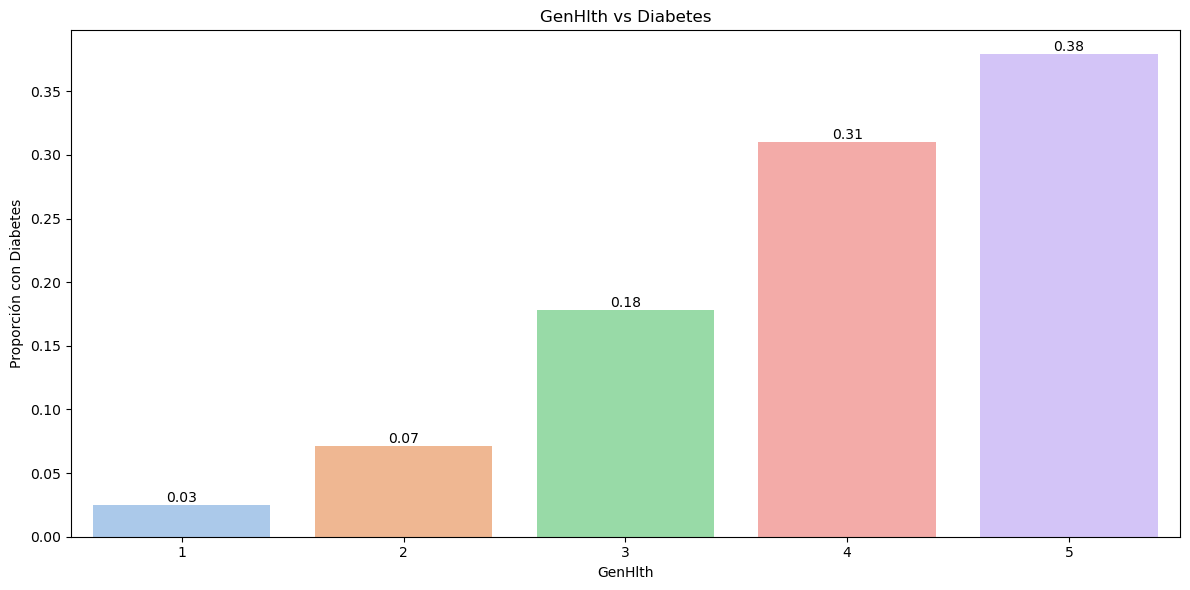


=== AGE ===


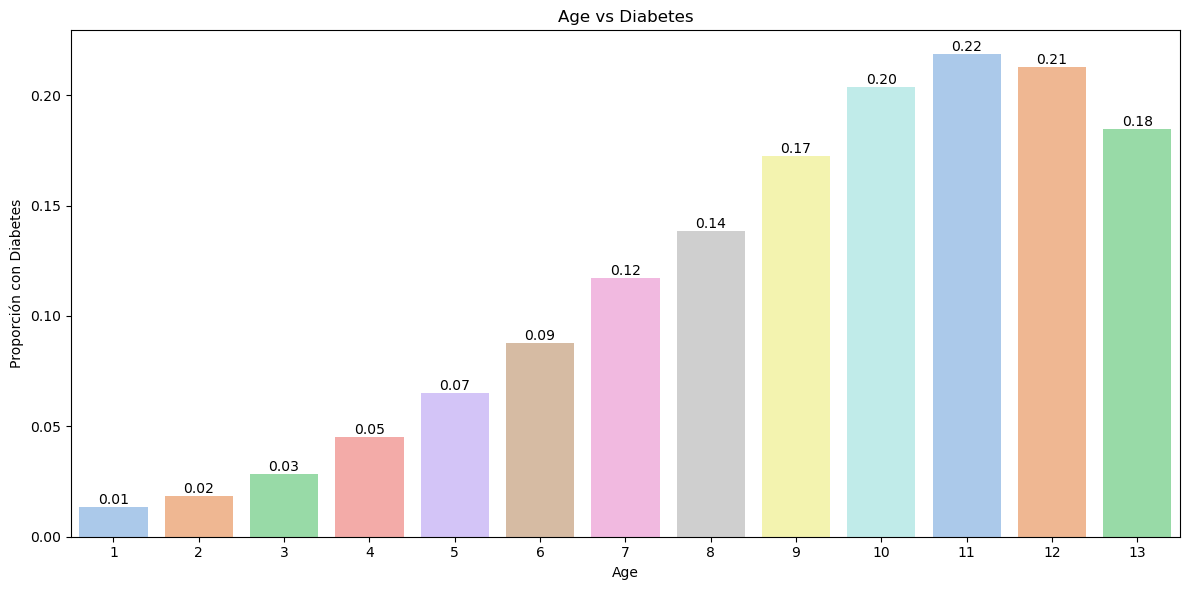


=== EDUCATION ===


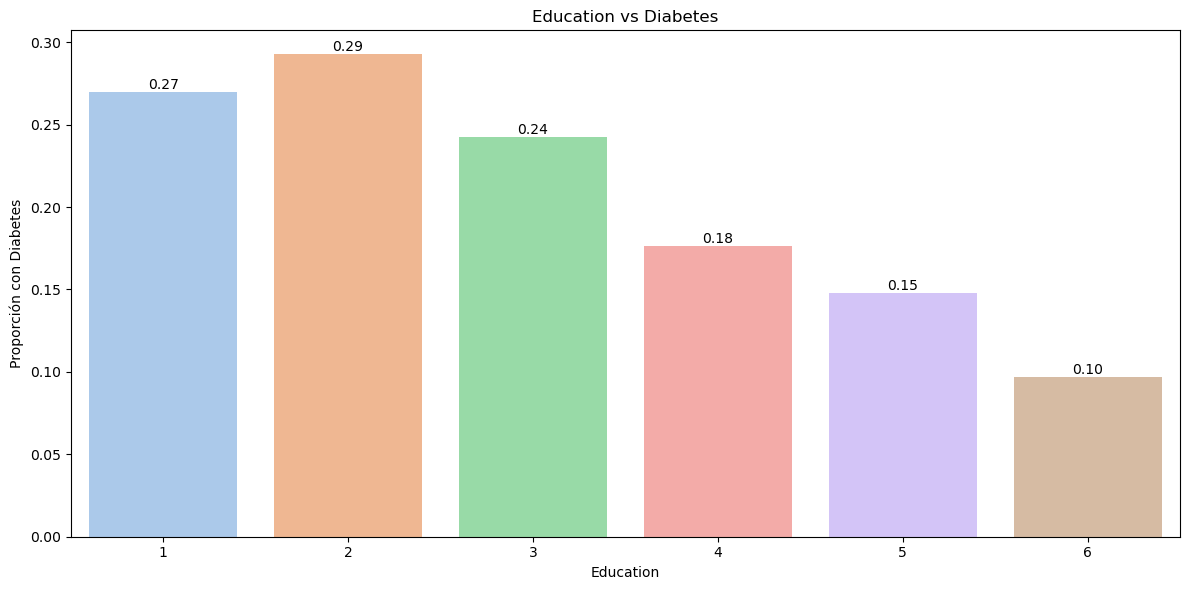


=== INCOME ===


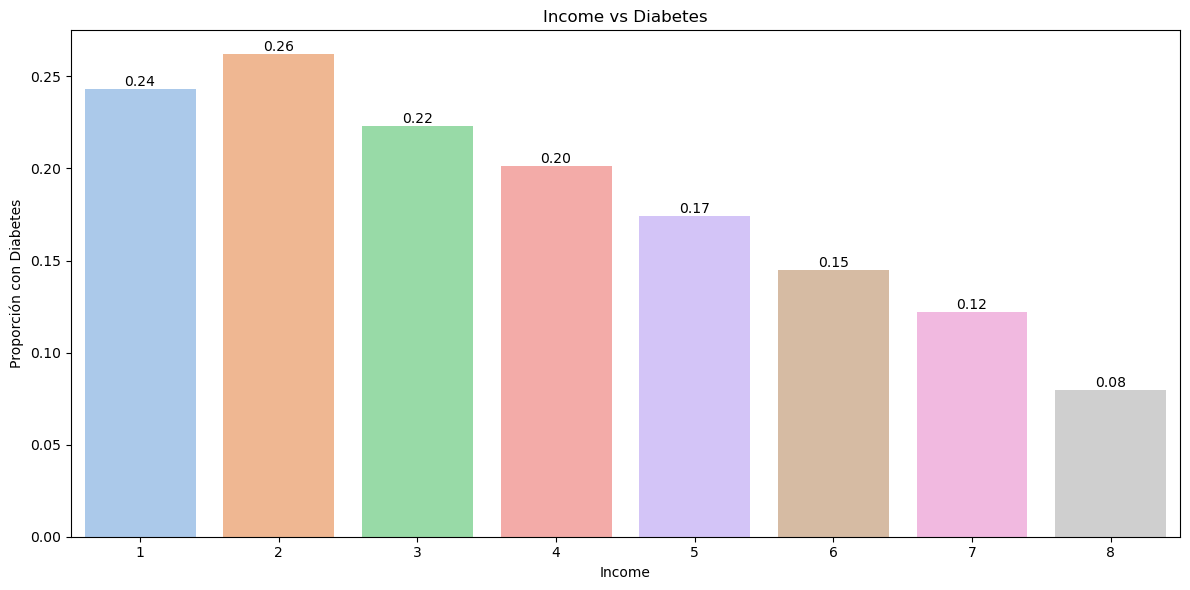

In [17]:
for col in categoricas:
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        x=col, 
        y='Diabetes_binary', 
        data=df, 
        palette='pastel',
        errorbar=None  
    )
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")
        
    plt.title(f'{col} vs Diabetes')
    plt.ylabel('Proporción con Diabetes')
    plt.tight_layout()
    plt.show()

Los resultados muestran una relación clara entre la proporción de personas con diabetes y diversas variables sociodemográficas. En cuanto al estado general de salud percibido `GenHlth`, se observa que a medida que las personas reportan una peor salud (del valor 1 al 5), la proporción de casos de diabetes aumenta progresivamente, lo que indica una fuerte asociación entre la autopercepción negativa de la salud y la presencia de diabetes. 

En relación con la `Age`, los datos revelan una tendencia ascendente en la proporción de diabetes conforme se avanza en los grupos etarios, alcanzando su punto máximo en los grupos de mayor edad, lo que sugiere que la diabetes es más común en adultos mayores. 

Por otro lado, los niveles de `Education` muestran una tendencia inversa: las personas con menor nivel educativo presentan una mayor proporción de diabetes, mientras que a mayor nivel educativo, esta proporción disminuye gradualmente. 

Esta misma tendencia se refleja en los niveles de `Income`, donde las personas con ingresos más bajos muestran una mayor prevalencia de diabetes en comparación con aquellas que pertenecen a grupos de ingresos más altos. En conjunto, estos resultados evidencian la influencia significativa de factores sociales como la edad, la educación, el ingreso económico y la percepción de salud en la prevalencia de la diabetes, resaltando la importancia de abordar esta enfermedad desde un enfoque multidimensional.

### **Variables Númericas vs Diabetes**

Se visualiza la asociación entre variables numéricas y la diabetes. Los gráficos combinan barras (proporción de diabetes por valor) y una línea de tendencia (roja), permitiendo identificar patrones o relaciones monotónicas entre las variables predictoras y la variable objetivo.

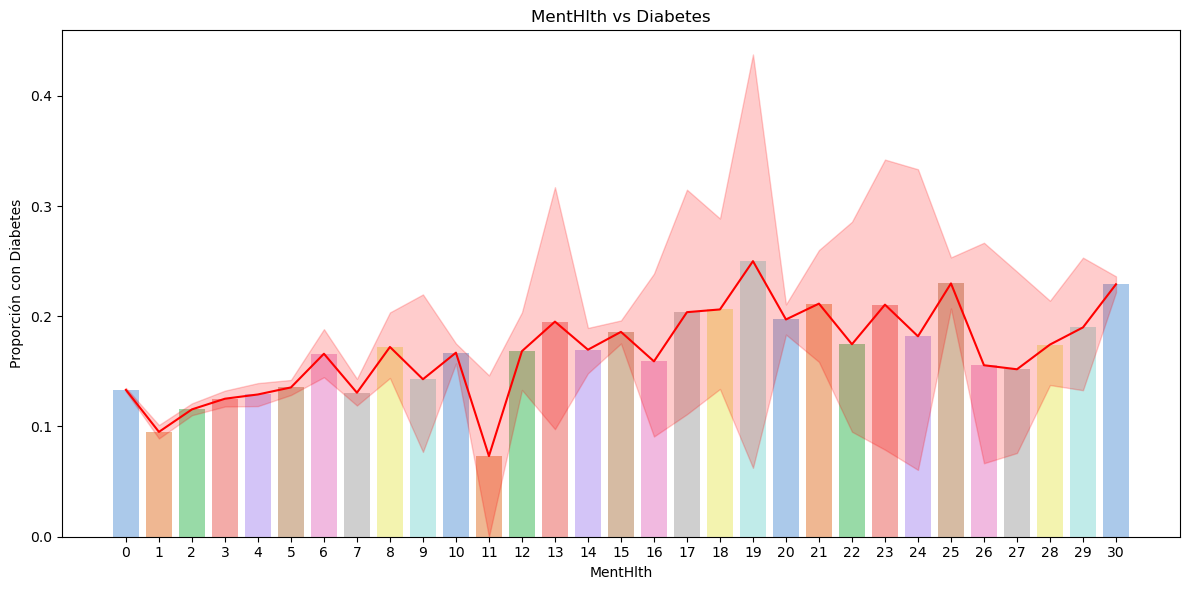

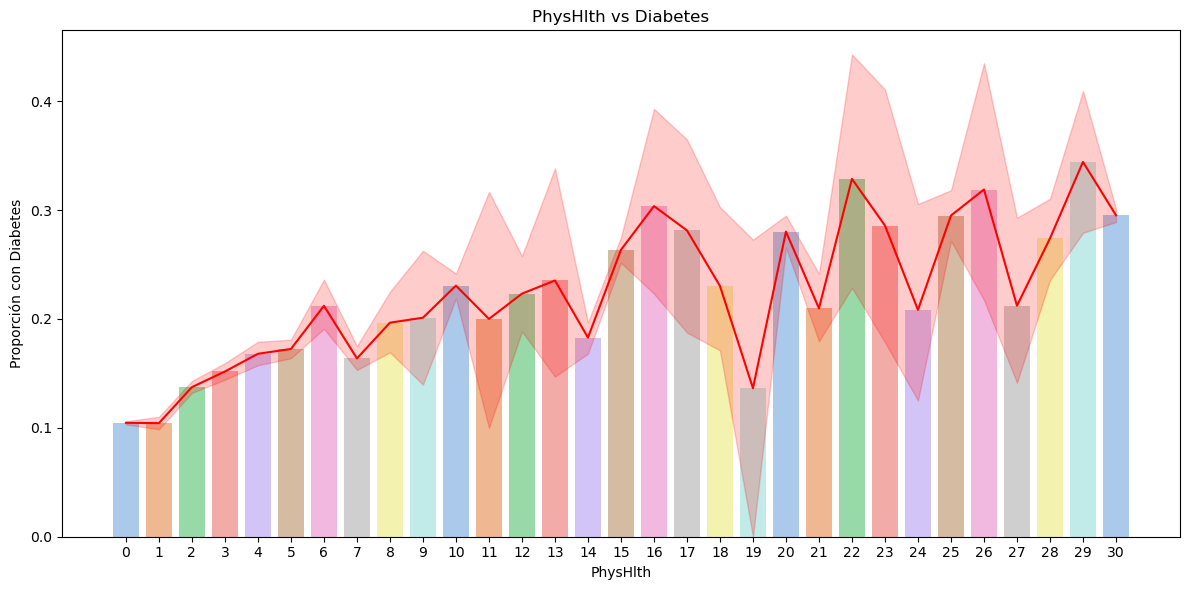

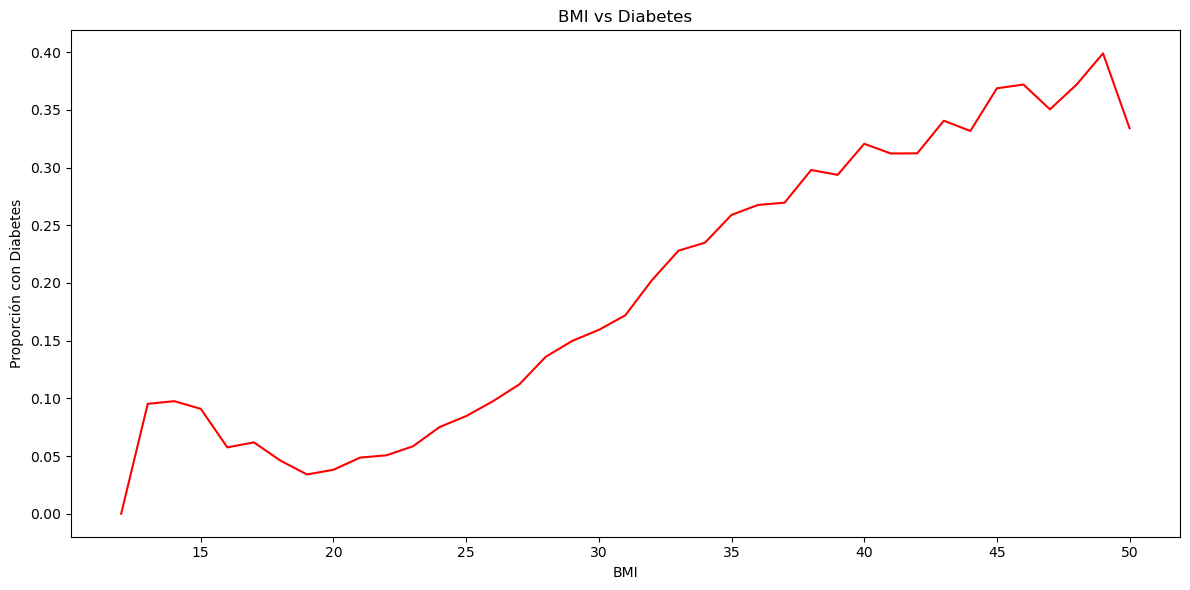

In [18]:
for col in numericas:
    
    if (col != "BMI"):
        plt.figure(figsize=(12, 6))
        sns.barplot(
            x=col, 
            y='Diabetes_binary', 
            data=df, 
            palette='pastel',
            errorbar=None  
        )
        
        sns.lineplot(
        x=col, 
        y='Diabetes_binary', 
        data=df,
        color='red',
        sort=True
        )
        plt.title(f'{col} vs Diabetes')
        plt.ylabel('Proporción con Diabetes')
        plt.tight_layout()
        plt.show()
        
             
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='BMI', 
    y='Diabetes_binary', 
    data=df,
    color='red',
    estimator='mean', 
    errorbar=None
)
plt.title('BMI vs Diabetes')
plt.ylabel('Proporción con Diabetes')
plt.tight_layout()
plt.show()

Los gráficos muestran la relación entre la salud mental `MentHith` y física `PhysHith` con la proporción de casos de diabetes. En ambos casos, se observa una tendencia clara: a medida que empeora el estado de salud (aumentan los valores en los ejes horizontales), la proporción de personas con diabetes incrementa. 

Para la salud mental, la línea de tendencia roja presenta un ascenso sostenido, aunque con cierta variabilidad en los valores intermedios, lo que sugiere que los días con mayor afectación mental están asociados a una mayor prevalencia de diabetes. Por otro lado, en la salud física, la tendencia es más marcada y consistente, especialmente en los valores más altos, indicando una fuerte correlación entre el deterioro físico y la presencia de diabetes. Estos resultados refuerzan la hipótesis de que tanto la salud mental como física están vinculadas al riesgo de diabetes, siendo el impacto particularmente evidente en estados de salud más críticos.

El gráfico de la relación entre el `BMI` y la proporción de diabetes muestra una tendencia claramente creciente y aparentemente lineal a medida que aumenta el índice de masa corporal, desde valores alrededor de 20 hasta aproximadamente 40-45 BMI. A partir de ese punto, la proporción de diabetes comienza a estabilizarse e incluso a descender ligeramente en el rango de valores más altos (45-50 BMI). Este comportamiento en las colas podría deberse a la menor cantidad de datos disponibles en dichos rangos extremos, lo que introduce una mayor variabilidad y ruido en las estimaciones. Por ejemplo, es posible que en algunos intervalos de BMI muy altos haya muy pocas observaciones, lo que resulta en proporciones que no necesariamente reflejan una tendencia poblacional real, sino fluctuaciones muestrales. Por lo tanto, aunque la relación positiva entre BMI y diabetes es evidente en la mayoría del rango, se debe tener precaución al interpretar las zonas extremas por posibles problemas de representatividad estadística.

### **Análisis de Tendencia por Categorización para Variables Numéricas**

Para evaluar patrones de asociación entre las variables numéricas y la prevalencia de diabetes, se implementó una estrategia de categorización basada en rangos clínicamente relevantes. Este abordaje permite:

- **Visualizar tendencias epidemiológicas** mediante agrupaciones interpretables.
- **Establecer puntos de corte clínicos** que faciliten la interpretación médica.
- **Capturar efectos umbral** que podrían perderse en análisis de correlación lineal.


=== MENTHLTH ===


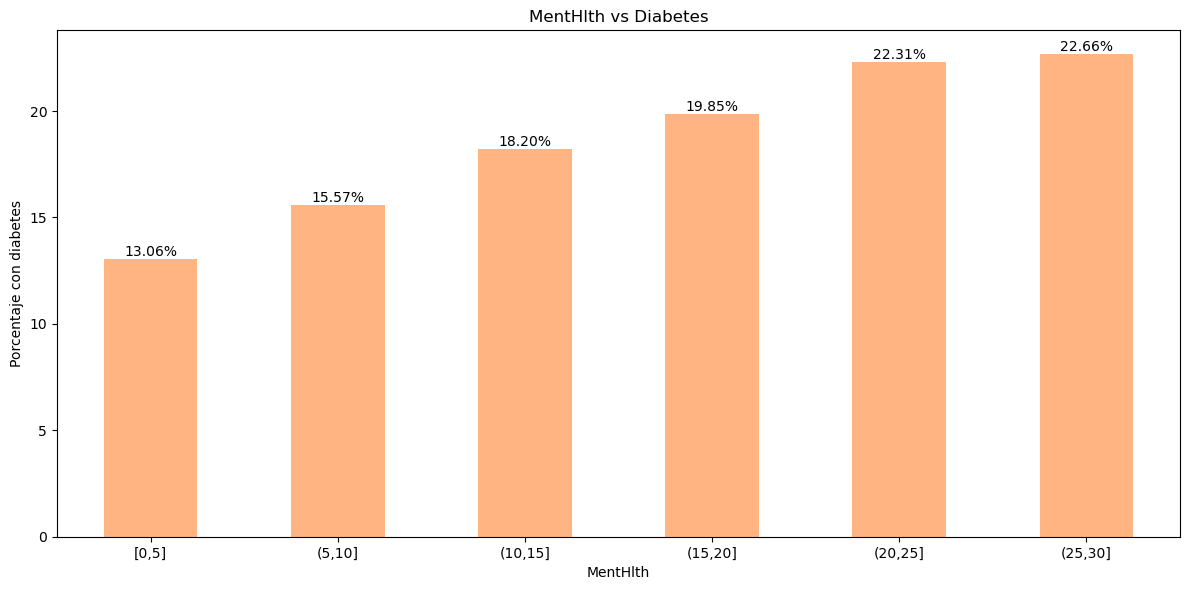


=== PHYSHLTH ===


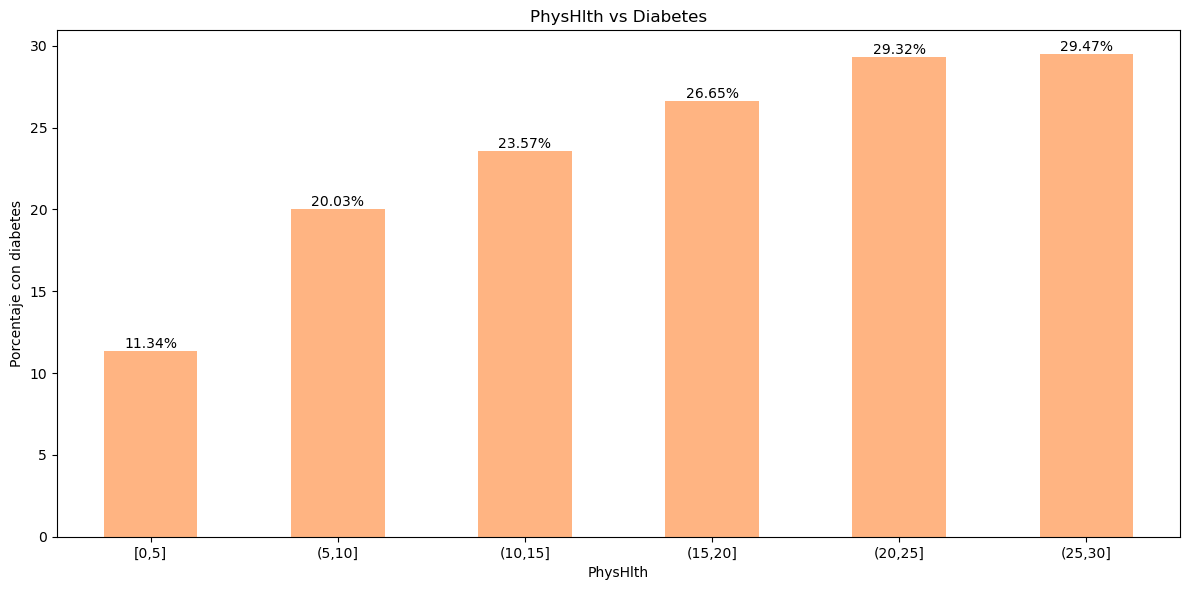


=== BMI ===


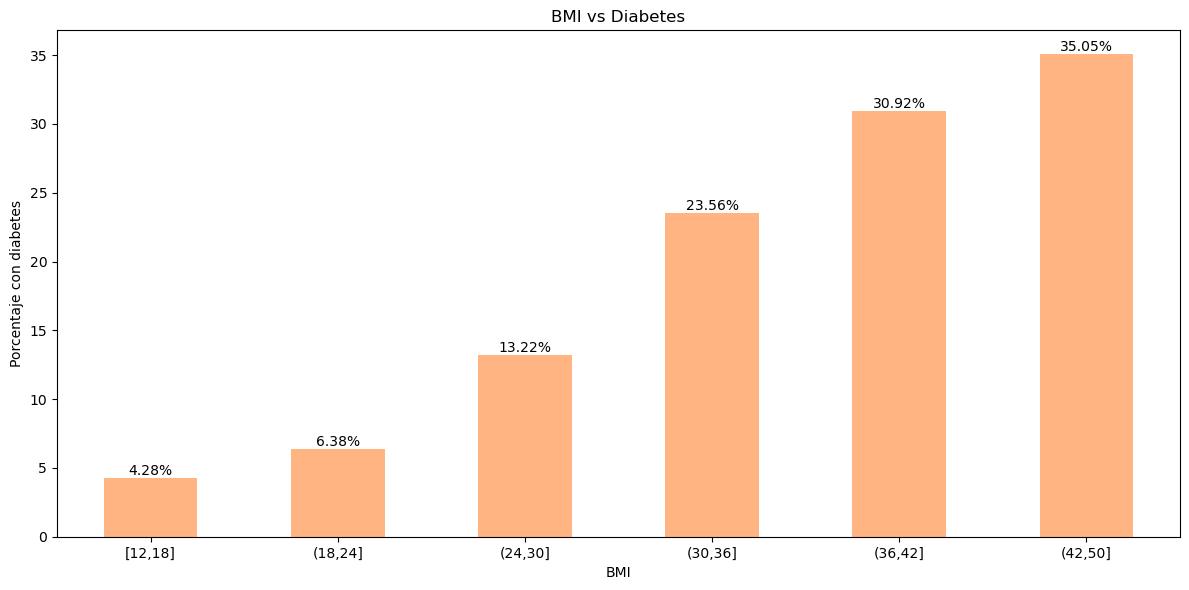

In [19]:
config_categorias = {
    "BMI": {
        "bins": [11, 19, 25, 31, 37, 43, 51],
        "labels": ['[12,18]', '(18,24]', '(24,30]', '(30,36]', '(36,42]', '(42,50]']
    },
    "MentHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    },
    "PhysHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    }
}

for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    
    bins = config_categorias[col]["bins"]
    labels = config_categorias[col]["labels"]
    
    
    grupos = pd.cut(df[col], bins=bins, labels=labels)
    

    diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100
    
    plt.figure(figsize=(12, 6))
    
    ax = diabetes_percent.plot(kind='bar', color=colors[1])
    ax.bar_label(ax.containers[0], fmt='%.2f%%', fontsize=10)
    
    plt.title(f'{col} vs Diabetes')
    plt.ylabel('Porcentaje con diabetes')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Estos gráficos corroboran claras asociaciones entre la diabetes y diversos factores relacionados con la salud física, mental y el Índice de Masa Corporal. En primer lugar, se evidencia una relación directa entre el deterioro de la salud mental y el aumento en la proporción de personas con diabetes. A medida que se incrementan los días con problemas de salud mental, también aumenta el porcentaje de personas con diagnóstico de diabetes, lo que sugiere una posible interacción entre el bienestar psicológico y el desarrollo o manejo de esta enfermedad.

De manera similar, la salud física también muestra una tendencia marcada: las personas que reportan más días con limitaciones físicas o problemas de salud presentan una mayor prevalencia de diabetes. Esto podría indicar que la diabetes tiende a coexistir con otras condiciones físicas crónicas o que su presencia contribuye al deterioro del estado físico general.

Finalmente, el índice de masa corporal muestra una relación especialmente clara: a medida que el BMI aumenta, también lo hace el porcentaje de personas con diabetes. Las tasas más altas se encuentran en los grupos con obesidad severa, lo que refuerza la fuerte asociación entre el exceso de peso y el riesgo de desarrollar diabetes.

---

También, con el objetivo de identificar la relación entre las variables numéricas predictoras y la variable objetivo (`Diabetes_binary`), se genera una serie de diagramas de caja (boxplots). Esta visualización permite comparar la distribución (mediana, rango intercuartílico) de cada variable numérica segmentada por la clase de diagnóstico, facilitando la observación de diferencias significativas entre los grupos que podrían ser patrones predictivos clave.


=== MENTHLTH ===


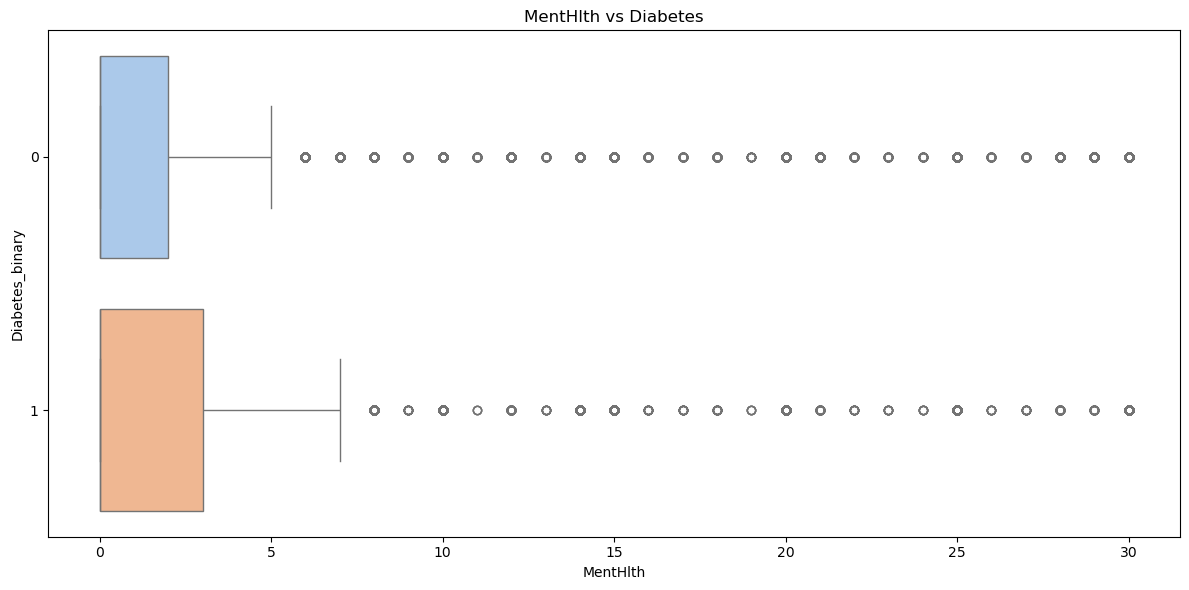


=== PHYSHLTH ===


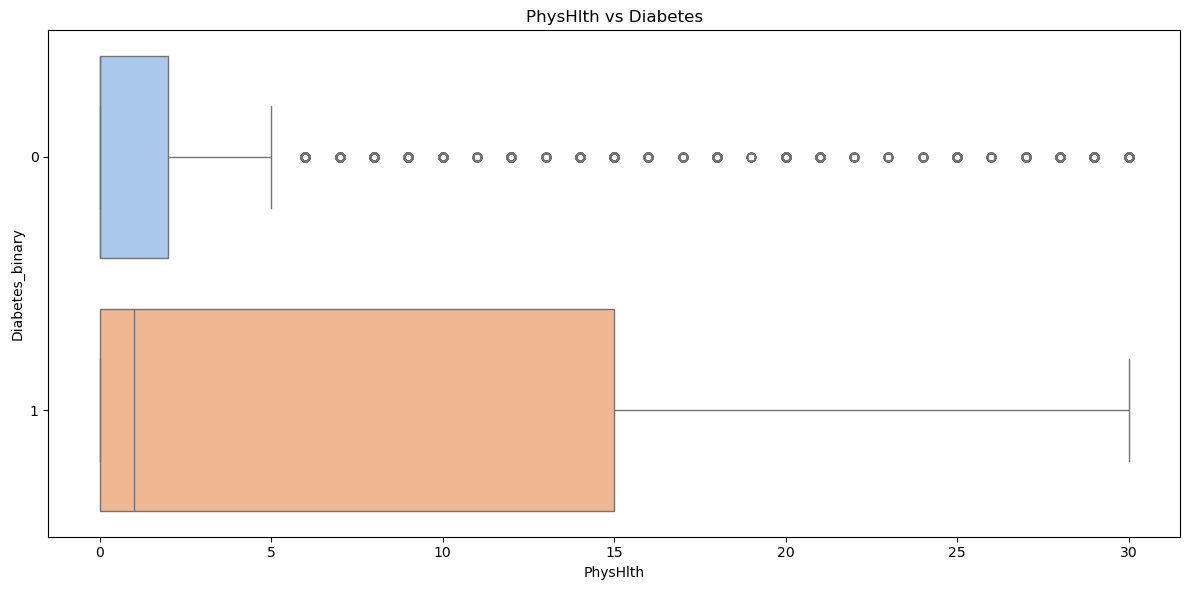


=== BMI ===


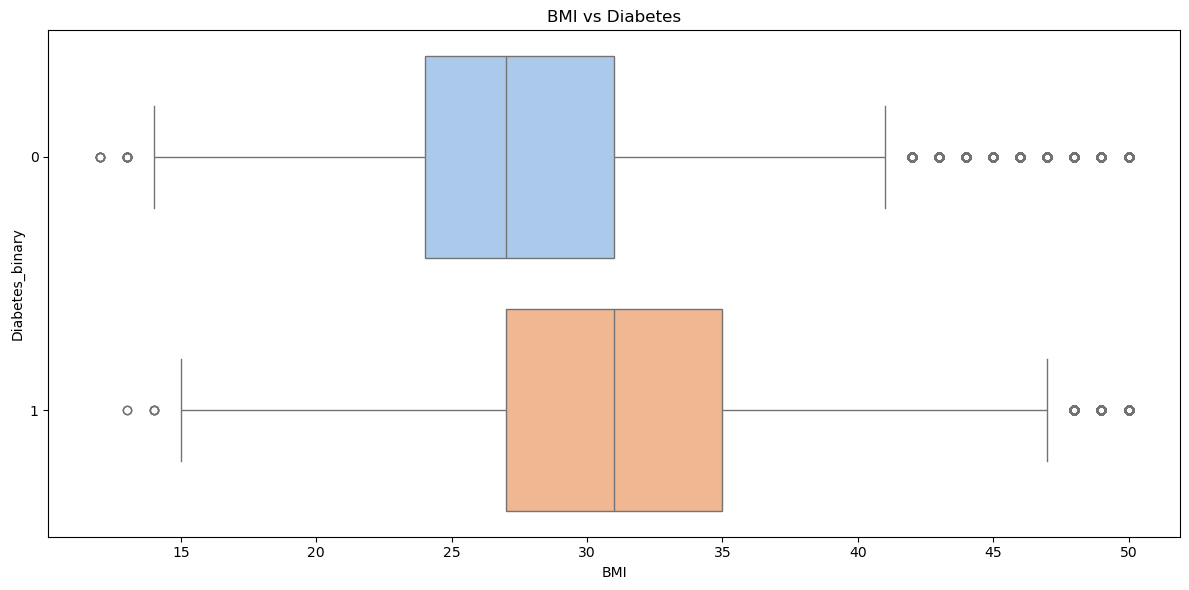

In [20]:
for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=col,          
        y='Diabetes_binary',        
        data=df, 
        palette='pastel', 
        orient='h'      
    )
    plt.title(f'{col} vs Diabetes') 
    
    plt.tight_layout()
    plt.show()

**MentHlth vs Diabetes**

**Interpretación**: Ambos grupos tienen la misma mediana (0 días). Aunque, las personas con diabetes tienden a reportar ligeramente más días de mala salud mental que quienes no la tienen. Esto sugiere que podría existir una relación débil pero positiva entre la diabetes y el deterioro del bienestar mental.

**PhysHlth vs Diabetes**

* El grupo **sin diabetes (0)** tiene una mediana muy baja (0 días).
* El grupo **con diabetes (1)** muestra una mediana un poco mayor (alrededor de 1 día) y una gran dispersión.

**Interpretación:** Las personas con diabetes/prediabetes reportan significativamente más días con mala salud física. Esto refleja un impacto claro de la enfermedad en el bienestar físico general.

**BMI vs Diabetes**

* El grupo **sin diabetes (0)** presenta una mediana cercana a **27–28** (sobrepeso leve).
* El grupo **con diabetes (1)** tiene una mediana más alta, alrededor de **32–33** (obesidad).

**Interpretación:** El índice de masa corporal es mayor en personas con diabetes, lo cual coincide con la evidencia médica: el sobrepeso y la obesidad son factores de riesgo importantes para desarrollar diabetes.


**Las personas con diabetes tienden a mostrar:**

  * Peor salud **física** (más días enfermos).
  * Peor salud **mental**, aunque en menor grado.
  * Mayor índice de masa corporal, lo que refuerza su relación con el riesgo de diabetes.

En conjunto, los boxplots muestran un patrón coherente: la diabetes se asocia con un **deterioro de la salud general** y **mayor peso corporal**.


## **Análisis Multivariado de Correlaciones**

Para identificar patrones de asociación lineal entre las distintas variables contenidas en el conjunto de datos, se llevó a cabo un análisis de correlación exhaustivo que examinó sistemáticamente las relaciones por pares entre todos los indicadores disponibles. Este enfoque metodológico permitió cuantificar el grado y la dirección de las interdependencias existentes dentro del ecosistema de variables relacionadas con la diabetes.

**Consideración metodológica y limitaciones de visualización:** En la fase inicial del análisis, se contempló la implementación de representaciones gráficas convencionales para visualizar la matriz de correlaciones completa, específicamente mediante el uso de heatmaps o mapas de calor. Sin embargo, tras una evaluación detallada, esta aproximación demostró ser impractical debido a la alta dimensionalidad del dataset. La significativa cantidad de variables resultó en una densidad de información excesiva que, incluso mediante ajustes iterativos en las dimensiones del gráfico, la escala de representación y los parámetros de visualización, generaba una superposición de elementos que impedía una interpretación visual efectiva y una legibilidad adecuada de las etiquetas y valores numéricos.

**Estrategia analítica implementada:** Como alternativa metodológica para superar estas limitaciones de visualización y priorizar la claridad interpretativa, se estableció un criterio de filtrado basado en la magnitud del coeficiente de correlación. Se definió un umbral de |r| > 0.30 para seleccionar, filtrar y presentar exclusivamente aquellas correlaciones que pueden considerarse moderadas a fuertes en términos de su intensidad.

In [21]:
df_heatmap = df[numericas + binarias + categoricas]

corr_matrix = df_heatmap.corr()

corr = corr_matrix.unstack()
corr = corr[corr.index.get_level_values(0) != corr.index.get_level_values(1)]

seen_pairs = set()
unique_corr = {}

for pair, value in corr.items():
    sorted_pair = tuple(sorted(pair))
    if sorted_pair not in seen_pairs:
        seen_pairs.add(sorted_pair)
        unique_corr[pair] = value

unique_corr_series = pd.Series(unique_corr)
strong_corr = unique_corr_series[(unique_corr_series.abs() > 0.30)].sort_values(
    key=lambda x: abs(x), ascending=False
)

print("Correlaciones con |r| > 0.30:")
print("-------------------------------------")
for pair, value in strong_corr.items():
    print(f"{pair} → {value:.6f}")

Correlaciones con |r| > 0.30:
-------------------------------------
('PhysHlth', 'GenHlth') → 0.524364
('PhysHlth', 'DiffWalk') → 0.478417
('DiffWalk', 'GenHlth') → 0.456920
('Education', 'Income') → 0.449106
('GenHlth', 'Income') → -0.370014
('MentHlth', 'PhysHlth') → 0.353619
('HighBP', 'Age') → 0.344452
('DiffWalk', 'Income') → -0.320124
('MentHlth', 'GenHlth') → 0.301674
('HighBP', 'GenHlth') → 0.300530


- **`PhysHlth` & `GenHlth` (r = 0.52)**: Los días de salud física deficiente se asocian fuertemente con una percepción de salud precaria, sugiriendo que el deterioro físico tangible impacta directamente la autovaloración general de salud.

- **`PhysHlth` & `DiffWalk` (r = 0.47)**: Existe una relación importante entre los días de salud física deficiente y las dificultades para caminar, indicando que los problemas de movilidad están vinculados a episodios de enfermedad o lesión física.

- **`GenHlth` & `DiffWalk` (r = 0.45)**: Las personas que reportan salud deficiente presentan mayores dificultades para caminar, sugiriendo que la percepción de salud deteriorada está asociada a limitaciones funcionales.

- **`Education` & `Income` (r = 0.44)**: Los graduados universitarios tienden a pertenecer a grupos de mayores ingresos, confirmando la conocida relación entre educación superior y nivel socioeconómico.

- **`PhysHlth` & `MentHlth` (r = 0.35)**: Los días de salud física y mental deficiente muestran una covariación moderada, respaldando la conexión mente-cuerpo donde el malestar físico coexiste con afectación psicológica.

**Hallazgo Principal**: Las correlaciones más fuertes involucran variables de salud física y funcional, mientras que las relaciones socioeconómicas, aunque presentes, muestran magnitudes moderadas.

## **Análisis de Correlaciones con la Variable Objetivo**

Para determinar qué variables presentan asociación lineal más fuerte con la condición de diabetes/prediabetes, se analizaron las correlaciones específicas con la variable objetivo `Diabetes_binary`. Este análisis permite priorizar los factores de riesgo más influyentes y comprender qué indicadores de salud podrían tener mayor poder predictivo en los modelos. La visualización presenta las 10 variables con mayor correlación absoluta, destacando tanto las relaciones positivas (factores de riesgo) como negativas (factores protectores) con la condición diabética, proporcionando una guía valiosa para la interpretación clínica de los resultados del modelado.

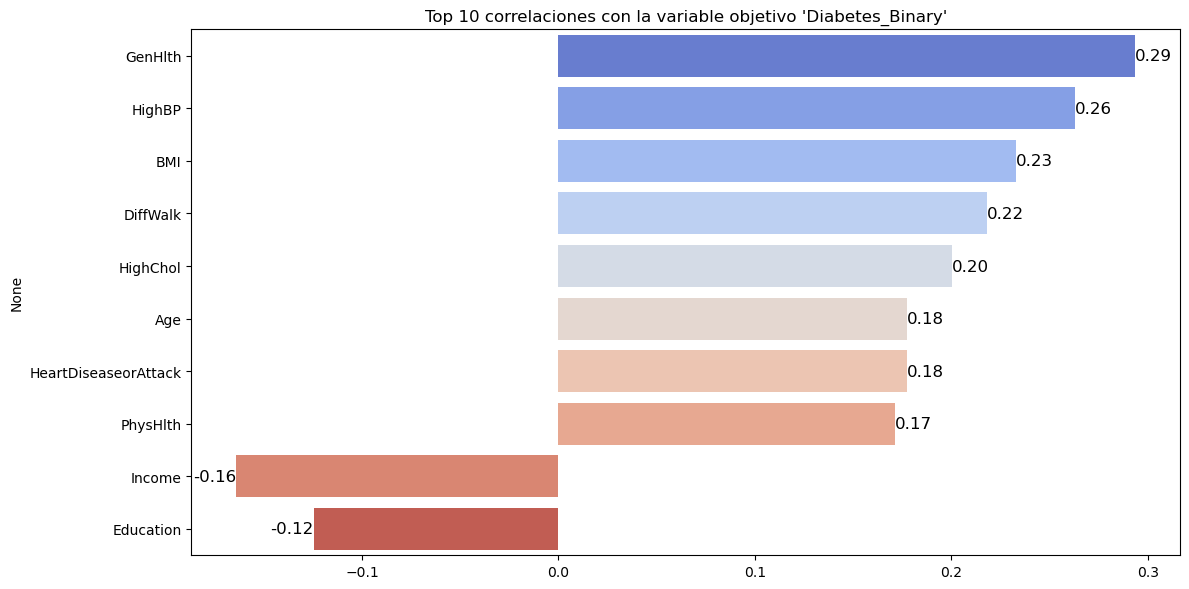

In [22]:
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=target_corr.head(10).values,
    y=target_corr.head(10).index,
    palette="coolwarm"
)

plt.title("Top 10 correlaciones con la variable objetivo 'Diabetes_Binary'")

for i, value in enumerate(target_corr.head(10).values):
    ax.text(
        value + 0.0 if value > 0 else value - 0.0,
        i,
        f"{value:.2f}",
        color='black',
        va='center',
        ha='left' if value > 0 else 'right',
        fontsize=12
    )

plt.tight_layout()
plt.show()


**Factores de Riesgo Positivos (Correlación > 0)**

- **`GenHlth` (0.29)**: Una negativa percepción de salud se traduce en un factor de riesgo para Diabetes.

- **`HighBP` (0.26)**: La **presión arterial alta** muestra correlación fuerte, confirmando su papel como principal factor de riesgo cardiovascular asociado a diabetes.

- **`BMI` (0.23)**: El **índice de masa corporal** presenta alta asociación, respaldando la obesidad como determinante crítico en la fisiopatología diabética.

- **`DiffWalk` (0.22)**: Las **dificultades para caminar** sugieren posibles complicaciones relacionadas con diabetes avanzada.

- **`HighChol` (0.20)**: El **colesterol elevado** aparece como quinto factor, reflejando la comorbilidad entre dislipidemia y resistencia a la insulina.

- **`HeartDiseaseorAttack` (0.18)**: La **enfermedad cardiovascular** confirma el síndrome metabólico como entidad interconectada.

- **`PhysHlth` (0.17)**: Los **días de salud física deficiente** reflejan el impacto en la calidad de vida.

**Dominan variables clínicas objetivas** (HighBP, BMI, HighChol) sobre las subjetivas, con un **gradiente claro en salud general**: a mejor autopercepción, menor riesgo diabético. La combinación sugiere que tanto indicadores biomédicos como la autovaloración del paciente son relevantes para la predicción.

## **Análisis de Multicolinealidad**

A continuación hallamos el VIF el cual determina la fuerza de la correlación entre las variables independientes. Se pronostica tomando una variable y comparándola con todas las demás. La puntuación VIF de una variable independiente representa hasta qué punto la variable se explica por otras variables independientes.

- Un valor `VIF de 1`: Sin multicolinealidad (variable perfectamente independiente).
- Un valor `VIF entre 1 y 5`: Multicolinealidad baja a moderada (no se considera problemática).
- Un valor `VIF entre 5 y 10`: Multicolinealidad moderada a alta (considerada problemática).
- Un valor `VIF superior a 10`: Multicolinealidad alta (preocupación grave, requiere medidas).

In [23]:
binarias.remove("Diabetes_binary")

df_vif = df[numericas + binarias + categoricas]

def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop = True)
    return(VIF)

VIF_mat = VIF_calculation(df_vif)
display(VIF_mat)


,variable,VIF
0,Education,29.650791
1,CholCheck,23.366858
2,BMI,20.978563
3,AnyHealthcare,20.914769
4,Income,14.170741
5,GenHlth,10.866551
6,Age,9.884412
7,Veggies,5.828922
8,PhysActivity,4.645181
9,Fruits,3.032774


#### **Tratamiento de Multicolinealidad**

Procedemos a tratar la multicolinealidad mediante la eliminación iterativa de variables con Factor de Inflación de la Varianza (VIF) superior a 10. Este enfoque sistemático nos permite identificar y remover las variables que presentan alta correlación con otras variables predictoras, lo que podría distorsionar los coeficientes del modelo y afectar su interpretabilidad. El proceso se repite de forma iterativa hasta que todas las variables restantes muestran un VIF por debajo del umbral establecido, garantizando así la independencia entre los predictores y mejorando la estabilidad de las estimaciones del modelo. 


In [24]:
removed_features = []
threshold = 10

print("Proceso iterativo de eliminación por VIF:")
print("-----------------------------------------")

for i in range(df_vif.shape[1]): 
    vif_df = VIF_calculation(df_vif)
    max_vif = vif_df['VIF'].iloc[0]
    max_feature = vif_df['variable'].iloc[0]
    
    if max_vif > threshold:
        print(f"Round {i+1}: Eliminando '{max_feature}' con VIF = {max_vif:.2f}")
        df_vif.drop(columns=[max_feature], inplace=True)
        removed_features.append(max_feature)
    else:
        print(f"\n¡Proceso completado! Todas las variables tienen VIF < {threshold}.")
        break

Proceso iterativo de eliminación por VIF:
-----------------------------------------


Round 1: Eliminando 'Education' con VIF = 29.65
Round 2: Eliminando 'CholCheck' con VIF = 22.48
Round 3: Eliminando 'AnyHealthcare' con VIF = 18.35
Round 4: Eliminando 'BMI' con VIF = 16.48

¡Proceso completado! Todas las variables tienen VIF < 10.


#### **Análisis del Proceso de Eliminación**

El proceso iterativo de VIF identificó y eliminó cuatro variables con alta multicolinealidad, siguiendo una secuencia que revela interesantes patrones en la estructura de los datos:

**Jerarquía de Eliminación:**
1. **Education** (VIF = 29.65) - Mayor redundancia informativa.
2. **CholCheck** (VIF = 22.48) - Alta redundancia .
3. **AnyHealthcare** (VIF = 18.35) - Redundancia significativa.
4. **BMI** (VIF = 16.48) - Redundancia moderada-alta.

#### **Decisión Estratégica: Preservación Selectiva**

A pesar de los altos valores de VIF, se tomó la decisión consciente de preservar **Education** y **BMI** basándose en criterios sustantivos que trascienden los umbrales estadísticos:

**Education:**
- Se encuentra entre las **10 variables más correlacionadas** con diabetes.
- Representa un **determinante social fundamental** de la salud.
- Su exclusión comprometería la validez del modelo.

**BMI:**
- Se encuentra entre las **10 variables más correlacionadas** con diabetes.
- **Variable clínicamente irreductible** en modelos de diabetes.
- Presenta **evidencia sólida** en literatura médica internacional.
- Factor de riesgo **modificable** con implicaciones prácticas directas.

**Conclusión:** La decisión de preservar Education y BMI representa una **sofisticación analítica superior** que prioriza la **relevancia sustantiva** sobre la pureza estadística, reconociendo que en ciencias de la salud algunos constructos críticos inevitablemente presentan solapamiento informativo debido a la complejidad de los fenómenos biológicos y sociales. Este enfoque balanceado asegura que el modelo resultante no solo sea estadísticamente sólido, sino también clínicamente significativo y epidemiológicamente válido.

#### **Impacto de la Reducción de Multicolinealidad** 

**Para Modelos Lineales (Logistic Regression, SVM)**
- **Beneficio crítico**: Coeficientes estables e interpretables.
- **Reducción de varianza** en las estimaciones.

**Para Modelos Basados en Árboles (Random Forest, XGBoost, Decision Tree)**
- **Impacto mínimo**: Naturalmente robustos a multicolinealidad.
- **Pérdida limitada**: Pueden capturar patrones a través de variables correlacionadas restantes.
- **Mantienen capacidad** de predecir sin distorsiones por correlaciones.

**Validación de Robustez**
El proceso asegura que las **comparaciones entre modelos** sean justas y que la **selección final** no esté sesgada por problemas de multicolinealidad, particularmente importante dado el requisito de interpretabilidad en el contexto médico.